In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings
import math

from collections import deque

from jax import lax


import graphviz

2025-03-22 19:59:56.980740: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742682597.055800    7806 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742682597.084097    7806 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [4]:
print(jax.default_backend())

gpu


In [5]:
def flatten_pytree(params):
  values, tree_info = jax.tree_util.tree_flatten(params)

  no_leaves = len(values)
  shapes = []
  flattened = []

  for i in range(no_leaves):
    flattened.append(values[i].flatten())
    shapes.append(values[i].shape)

  return tree_info, shapes, jnp.concatenate(flattened)


def reconstruct_pytree(tree_info, shapes, flattened):

  values = []
  k = 0
  for i in range(len(shapes)):
    values.append(np.reshape(flattened[k:k+np.prod(shapes[i])], shapes[i]))
    k += np.prod(shapes[i])

  py_tree = jax.tree_util.tree_unflatten(tree_info, values)
  return py_tree

In [6]:
t0, tfinal = 0.0, 1.0

In [7]:
def TodaLatt(w, t):
    
    p1, p2, p3, p4, q1, q2, q3, q4 = w

    p1_t = -jnp.exp(q1 - q2) + jnp.exp(q4 - q1)
    q1_t = p1

    p2_t = jnp.exp(q1 - q2) - jnp.exp(q2 - q3)
    q2_t = p2

    p3_t = jnp.exp(q2 - q3) - jnp.exp(q3 - q4)
    q3_t = p3

    p4_t = jnp.exp(q3 - q4) - jnp.exp(q4 - q1)
    q4_t = p4
    

    dwdt = [p1_t, p2_t, p3_t, p4_t, q1_t, q2_t, q3_t, q4_t]

    return dwdt

In [8]:
@jax.jit
def calc_H(p1, p2, p3, p4, q1, q2, q3, q4) :

    H = (p1**2)/2 + (p2**2)/2 + (p3**2)/2 + (p4**2)/2 + jnp.exp(q1 - q2) + jnp.exp(q2 - q3) + jnp.exp(q3 - q4) + jnp.exp(q4 - q1)

    return H

In [9]:
Hmax = 2.0 + 2*(np.exp(2) + np.exp(-2))
Hmin = 4.0

print(Hmin, Hmax)

4.0 17.048782764334526


In [10]:
@jax.jit
def calc_ab(p1, p2, p3, p4, q1, q2, q3, q4) :

    a1 = -0.5*p1
    a2 = -0.5*p2
    a3 = -0.5*p3
    a4 = -0.5*p4

    b1 = 0.5*jnp.exp(0.5*(q1-q2))
    b2 = 0.5*jnp.exp(0.5*(q2-q3))
    b3 = 0.5*jnp.exp(0.5*(q3-q4))
    b4 = 0.5*jnp.exp(0.5*(q4-q1))

    return a1, a2, a3, a4, b1, b2, b3, b4

In [11]:
@jax.jit
def calc_evals(a1, a2, a3, a4, b1, b2, b3, b4) :

    c4 = 1

    c3 = -(a1 + a2 + a3 + a4)  
    
    c2 = (a1 * a2 + a1 * a3 + a1 * a4 + a2 * a3 + a2 * a4 + a3 * a4 - b1**2 - b2**2 - b3**2 - b4**2)
    
    c1 = (-a1 * a2 * a3 - a1 * a2 * a4 - a1 * a3 * a4 - a2 * a3 * a4 + a1 * b2**2 + a1 * b3**2 \
         + a2 * b3**2 + a2 * b4**2 + a3 * b1**2 + a3 * b4**2 + a4 * b1**2 + a4 * b2**2)
    
    c0 = (a1 * a2 * a3 * a4 - a1 * a2 * b3**2 - a1 * a4 * b2**2 - a2 * a3 * b4**2 - a3 * a4 * b1**2 \
        + b1**2 * b3**2 - 2 * b1 * b2 * b3 * b4 + b2**2 * b4**2)


    # # Gershgorin radii for each row
    # R1 = b1 + b4
    # R2 = b1 + b2
    # R3 = b2 + b3
    # R4 = b3 + b4

    # # Optimal initial guesses within each Gershgorin interval
    # initial_guesses = jnp.array([
    #     a1 - 0.5 * R1,  # Left of a1's interval
    #     a2 + 0.5 * R2,  # Right of a2's interval
    #     a3 - 0.5 * R3,  # Left of a3's interval
    #     a4 + 0.5 * R4   # Right of a4's interval
    # ])

    # # Durand-Kerner iteration
    # def durand_kerner_step(roots):
    #     new_roots = roots
    #     for i in range(4):
    #         denominator = 1.0
    #         for j in range(4):
    #             if j != i:
    #                 denominator *= (roots[i] - roots[j])
    #         new_root = roots[i] - (roots[i]**4 + c3*roots[i]**3 + c2*roots[i]**2 + c1*roots[i] + c0) / denominator
    #         new_roots = new_roots.at[i].set(new_root)
    #     return new_roots

    # # Apply iterations
    # roots = jax.lax.fori_loop(0, 20, lambda i, r: durand_kerner_step(r), initial_guesses)
    # evalsn = jnp.sort(roots)

    # # Compute the roots (eigenvalues)
    # evalsn = durand_kerner(c3, c2, c1, c0)
    # evalsn = jnp.sort(evalsn)

    
    L = jnp.array([[a1, b1, 0.0, b4], [b1, a2, b2, 0.0], [0.0, b2, a3, b3], [b4, 0.0, b3, a4]])

    evals = jnp.linalg.eigvalsh(L)

        # Normalize the quartic equation
    a, b, c, d, e = a / a, b / a, c / a, d / a, e / a

    # Compute the resolvent cubic equation coefficients
    p = c - (3 * b**2) / 8
    q = d + (b**3) / 8 - (b * c) / 2
    r = e - (3 * b**4) / 256 + (b**2 * c) / 16 - (b * d) / 4

    # Solve the resolvent cubic equation: y^3 + py^2 + (p^2/4 - r)y - q^2/8 = 0
    A = p**2 / 4 - r
    B = -q**2 / 8

    # Solve the depressed cubic equation
    discriminant = (B**2) / 4 + (A**3) / 27
    sqrt_discriminant = jnp.sqrt(discriminant)
    y = jnp.cbrt(-B / 2 + sqrt_discriminant) + jnp.cbrt(-B / 2 - sqrt_discriminant)

    # Compute the roots of the quartic equation
    sqrt_term = jnp.sqrt(y + p)
    sqrt_term = jnp.where(jnp.isnan(sqrt_term), 0.0, sqrt_term)  # Handle NaNs

    root1 = (-b / 4) + (sqrt_term + jnp.sqrt(-(3 * p + 2 * y + 2 * q / sqrt_term))) / 2
    root2 = (-b / 4) + (sqrt_term - jnp.sqrt(-(3 * p + 2 * y + 2 * q / sqrt_term))) / 2
    root3 = (-b / 4) - (sqrt_term + jnp.sqrt(-(3 * p + 2 * y - 2 * q / sqrt_term))) / 2
    root4 = (-b / 4) - (sqrt_term - jnp.sqrt(-(3 * p + 2 * y - 2 * q / sqrt_term))) / 2

    return jnp.array([root1, root2, root3, root4])

    # print(evals, evalsn)
    # print(jnp.linalg.norm(evals - evalsn, ord = jnp.inf))

    return evals

In [12]:
evals = calc_evals(1.0, 2.0, -3.0, 4.0, 4.1, 0.2, 0.3, 0.4)
print(evals)

[-3.06487813 -2.59352784  3.98134322  5.67706276]


In [13]:
@jax.jit
def calc_evals_pq(p1, p2, p3, p4, q1, q2, q3, q4) :

    a1, a2, a3, a4, b1, b2, b3, b4 = calc_ab(p1, p2, p3, p4, q1, q2, q3, q4)
    
    a1 = jnp.reshape(a1, (-1,))
    a2 = jnp.reshape(a2, (-1,))
    a3 = jnp.reshape(a3, (-1,))
    a4 = jnp.reshape(a4, (-1,))
    b1 = jnp.reshape(b1, (-1,))
    b2 = jnp.reshape(b2, (-1,))
    b3 = jnp.reshape(b3, (-1,))
    b4 = jnp.reshape(b4, (-1,))
    
    evals = jax.vmap(calc_evals, (0, 0, 0, 0, 0, 0, 0, 0), 0)(a1, a2, a3, a4, b1, b2, b3, b4)
    evals = jnp.reshape(evals, (-1,))
    
    return evals
    

In [14]:
def define_collocation_points(t_bdry, N=100):

    ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

    p1s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    p2s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    p3s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    p4s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    q1s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    q2s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    q3s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    q4s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    Hs = calc_H(p1s, p2s, p3s, p4s, q1s, q2s, q3s, q4s)

    evals = jax.vmap(calc_evals_pq, (0), 0)(p1s, p2s, p3s, p4s, q1s, q2s, q3s, q4s)
    Hs_test = 2*(evals[:, :1]**2 + evals[:, 1:2]**2 + evals[:, 2:3]**2 + evals[:, 3:]**2)

    ode_points = np.column_stack((ode_points, Hs, evals))
    zsensors = np.column_stack((p1s, p2s, p3s, p4s, q1s, q2s, q3s, q4s))
    
    return (ode_points, zsensors)

In [15]:
(de_points, zsensors) = define_collocation_points([t0, tfinal], 1000)
print(de_points.shape, zsensors.shape)

(1000, 6) (1000, 8)


In [16]:

# tcolloc = de_points[:, 0]
# print(tcolloc.shape)

# nump = tcolloc.shape[0]

# # Create scatter plot
# plt.scatter(tcolloc, np.zeros_like(tcolloc), marker='o')

# # Set the plot labels and title
# plt.xlabel("t")
# plt.ylabel("")
# plt.title("50 Collocation Points using LHS")

# # Adjust the y-axis to ensure visibility of points
# plt.yticks([])  # Hide y-ticks since all points are at y=0

# # Optionally, you can set the y-axis range to ensure visibility
# plt.ylim(-0.1, 0.1)

# # Save the plot first, before showing it
# #plt.savefig('50colloc_t1.0.png')

# # Display the plot
# plt.show()

In [17]:
Hmax_act = np.max(de_points[:, 1])
Hmin_act = np.min(de_points[:, 1])

print(Hmax, Hmax_act)
print(Hmin, Hmin_act)

17.048782764334526 13.189825351444997
4.0 4.218613211981704


In [18]:
# from scipy.optimize import minimize

# def funcmin(x):

#     return (x[0]**2)/2 + (x[1]**2)/2 + (x[2]**2)/2 + jnp.exp(x[3] - x[4]) + jnp.exp(x[4] - x[5]) + jnp.exp(x[5] - x[3])

# def funcmax(x):

#     return -1.0*((x[0]**2)/2 + (x[1]**2)/2 + (x[2]**2)/2 + jnp.exp(x[3] - x[4]) + jnp.exp(x[4] - x[5]) + jnp.exp(x[5] - x[3]))

# # Domain boundaries (x and y range from -5 to 5)
# bounds = [(-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0)]

# # Initial guess for the optimization algorithm
# initial_guess = [0.5, -0.5, 0.5, -0.5, 0.5, -0.5]

# # Minimize the function
# resultmin = minimize(funcmin, initial_guess, bounds=bounds)
# resultmax = minimize(funcmax, initial_guess, bounds=bounds)

# # Print the result
# print("Minimum value found:", resultmin.fun)
# print("At point:", resultmin.x)

# print("Maximum value found:", resultmax.fun)
# print("At point:", resultmax.x)

# print(5/2 + np.exp(2) + np.exp(-2))

In [19]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [20]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [21]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [22]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(8*self.units)(b)
    return out

In [23]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int 
  units: int

  @nn.compact
  def __call__(self, tHE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tHE.ndim == 1:
      tHE = jnp.reshape(tHE, (1,-1)) 

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:5]
    eval4_0 = tHE[:, 5:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    p1_0 = u[:, :1]
    p2_0 = u[:, 1:2]
    p3_0 = u[:, 2:3]
    p4_0 = u[:, 3:4]
    q1_0 = u[:, 4:5]
    q2_0 = u[:, 5:6]
    q3_0 = u[:, 6:7]
    q4_0 = u[:, 7:]

    u = jnp.column_stack((p1_0, p2_0, p3_0, p4_0, q1_0, q2_0, q3_0, q4_0))

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_p2 = trunk_net[:, self.units:2*self.units]
    trunk_p3 = trunk_net[:, 2*self.units:3*self.units]
    trunk_p4 = trunk_net[:, 3*self.units:4*self.units]
    trunk_q1 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q2 = trunk_net[:, 5*self.units:6*self.units]
    trunk_q3 = trunk_net[:, 6*self.units:7*self.units]
    trunk_q4 = trunk_net[:, 7*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_p2 = branch_net[:, self.units:2*self.units]
    branch_p3 = branch_net[:, 2*self.units:3*self.units]
    branch_p4 = branch_net[:, 3*self.units:4*self.units]
    branch_q1 = branch_net[:, 4*self.units:5*self.units]
    branch_q2 = branch_net[:, 5*self.units:6*self.units]
    branch_q3 = branch_net[:, 6*self.units:7*self.units]
    branch_q4 = branch_net[:, 7*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    p4 = CombineBranches()(trunk_p4, branch_p4)  
    q1 = CombineBranches()(trunk_q1, branch_q1)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    q3 = CombineBranches()(trunk_q3, branch_q3)
    q4 = CombineBranches()(trunk_q4, branch_q4)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    p4 = HardConstraint(self.t0, self.tfinal, p4_0)([t_0, p4])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])
    q4 = HardConstraint(self.t0, self.tfinal, q4_0)([t_0, q4])
      
    p1 = jnp.reshape(p1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    p4 = jnp.reshape(p4, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    q3 = jnp.reshape(q3, (-1,))
    q4 = jnp.reshape(q4, (-1,))

    return p1, p2, p3, p4, q1, q2, q3, q4

In [24]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, tHE, z):
    
    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:5]
    eval4_0 = tHE[:, 5:]
    
    p1_0 = z[:, :1]
    p2_0 = z[:, 1:2]
    p3_0 = z[:, 2:3]
    p4_0 = z[:, 3:4]
    q1_0 = z[:, 4:5]
    q2_0 = z[:, 5:6]
    q3_0 = z[:, 6:7]
    q4_0 = z[:, 7:]
    
    p1 = var(tHE, z, 0, params)
    p2 = var(tHE, z, 1, params)
    p3 = var(tHE, z, 2, params)
    p4 = var(tHE, z, 3, params)
    q1 = var(tHE, z, 4, params)
    q2 = var(tHE, z, 5, params)
    q3 = var(tHE, z, 6, params)
    q4 = var(tHE, z, 7, params)
    
    H = calc_H(p1, p2, p3, p4, q1, q2, q3, q4)
    H = jnp.reshape(H, (-1, 1))
    
    dp1_tHE = var_t(tHE, z, 0, params)
    dp2_tHE = var_t(tHE, z, 1, params)
    dp3_tHE = var_t(tHE, z, 2, params)
    dp4_tHE = var_t(tHE, z, 3, params)
    dq1_tHE = var_t(tHE, z, 4, params)
    dq2_tHE = var_t(tHE, z, 5, params)
    dq3_tHE = var_t(tHE, z, 6, params)
    dq4_tHE = var_t(tHE, z, 7, params)
        
    p1_t = dp1_tHE[:, 0]
    p2_t = dp2_tHE[:, 0]  
    p3_t = dp3_tHE[:, 0]
    p4_t = dp4_tHE[:, 0]
    q1_t = dq1_tHE[:, 0]
    q2_t = dq2_tHE[:, 0]
    q3_t = dq3_tHE[:, 0]
    q4_t = dq4_tHE[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q4 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - (jnp.exp(q2 - q3) - jnp.exp(q3 - q4))
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)

    p4_t_loss = p4_t - (jnp.exp(q3 - q4) - jnp.exp(q4 - q1))
    p4_t_loss = jnp.square(p4_t_loss)
    p4_t_loss = jnp.mean(p4_t_loss)
    
    q4_t_loss = q4_t - p4
    q4_t_loss = jnp.square(q4_t_loss)
    q4_t_loss = jnp.mean(q4_t_loss)
        
    diff_loss = p1_t_loss + p2_t_loss + p3_t_loss + p4_t_loss + q1_t_loss + q2_t_loss + q3_t_loss + q4_t_loss

    total_loss = diff_loss + H_loss

    return total_loss

@jax.jit
def train_step(params, pdes, z):
    t = pdes[:, :]
    
    return jax.value_and_grad(loss, has_aux = False)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [25]:
def train_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = optimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [26]:
deeponet = DeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 6), 1.0)
u_init = jnp.full((10, 8), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [27]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

33280


In [28]:
# epochs = 5000
# params, loss = train_network(params, de_points, zsensors, epochs)


In [29]:
# params_5000ep = copy.deepcopy(params)
tree_info, shapes, _ = flatten_pytree(params)
params_flat = jnp.load("P_t1.0_5000_ep_Toda4.npy")
params_5000ep = reconstruct_pytree(tree_info, shapes, params_flat)

params = copy.deepcopy(params_5000ep)

In [30]:
# tabulate_model = nn.tabulate(Foo(), jax.random.PRNGKey(0))

# print(tabulate_fn(x))

In [31]:
#params = copy.deepcopy(params_5000ep)

In [32]:
# import graphviz

# def plot_deeponet():
#     dot = graphviz.Digraph(comment='DeepONet')

#     # Add nodes for inputs
#     dot.node('t', 't')
#     dot.node('u_0', 'u0')

#     dot.node('trunk_input', 'Trunk Input Layer')
#     dot.node('branch_input', 'Branch Input Layer')
    
#     # Add Normalize layer between input and 1st MLP layer
#     dot.node('normalize_t', 'Normalize Layer')

#     # Add nodes for MLP layers in trunk network
#     dot.node('trunk_layer_1', 'Trunk Dense Layer 1 (MLP)')
#     dot.node('trunk_layer_2', 'Trunk Dense Layer 2 (MLP)')
#     dot.node('trunk_layer_3', 'Trunk Dense Layer 3 (MLP)')
#     dot.node('trunk_layer_4', 'Trunk Dense Layer 4 (MLP)')
    
#     # Add nodes for MLP layers in branch network
#     dot.node('branch_layer_1', 'Branch Dense Layer 1 (MLP)')
#     dot.node('branch_layer_2', 'Branch Dense Layer 2 (MLP)')
#     dot.node('branch_layer_3', 'Branch Dense Layer 3 (MLP)')
#     dot.node('branch_layer_4', 'Branch Dense Layer 4 (MLP)')
    
#     # Add nodes for outputs of trunk and branch networks
#     dot.node('trunk_output', 'Trunk Output Layer')
#     dot.node('branch_output', 'Branch Output Layer')

#     # Add Multiply Layer to combine trunk and branch outputs
#     dot.node('multiply_layer', 'Multiply Layer')

#     # Add Hard Constraint Layer
#     dot.node('hard_constraint', 'Hard Constraints Layer')

#     # Add Output Layer
#     dot.node('output_layer', 'Final Output Layer')

#     #dot.node('conservative_layer', 'Conservative Layer')

#     # Add edges to represent the data flow

#     # Inputs to normalize and MLP layers
#     dot.edge('t', 'normalize_t')

#     # Normalize Layer to Trunk Network
#     dot.edge('normalize_t', 'trunk_input')
#     dot.edge('u_0', 'branch_input')

#     dot.edge('trunk_input', 'trunk_layer_1')
#     dot.edge('branch_input', 'branch_layer_1')   

#     # Trunk network layers
#     dot.edge('trunk_layer_1', 'trunk_layer_2')
#     dot.edge('trunk_layer_2', 'trunk_layer_3')
#     dot.edge('trunk_layer_3', 'trunk_layer_4')

#     # Branch network layers
#     dot.edge('branch_layer_1', 'branch_layer_2')
#     dot.edge('branch_layer_2', 'branch_layer_3')
#     dot.edge('branch_layer_3', 'branch_layer_4')

#     # Trunk and branch outputs
#     dot.edge('trunk_layer_4', 'trunk_output')
#     dot.edge('branch_layer_4', 'branch_output')

#     # Multiply Layer combines trunk and branch outputs
#     dot.edge('trunk_output', 'multiply_layer')
#     dot.edge('branch_output', 'multiply_layer')

#     # Hard Constraint Layer
#     dot.edge('multiply_layer', 'hard_constraint')

#     # Output Layer
#     dot.edge('hard_constraint', 'output_layer')

#     #dot.edge('conservative_layer', 'output_layer')


#     # Render the graph
#     dot.render('deeponet_model_updated', format='png', cleanup=True)

# # Call the function to generate and save the diagram
# plot_deeponet()


In [33]:
# start = 0
# stop = 10000

# plt.semilogy(loss[start:stop])
# plt.legend(['Vanilla DN'])
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.title("Loss Function Error for Vanilla DeepONet")
# plt.grid()
# #plt.savefig('Toda3_vanilla_loss_5000ep.png')

(500, 4)


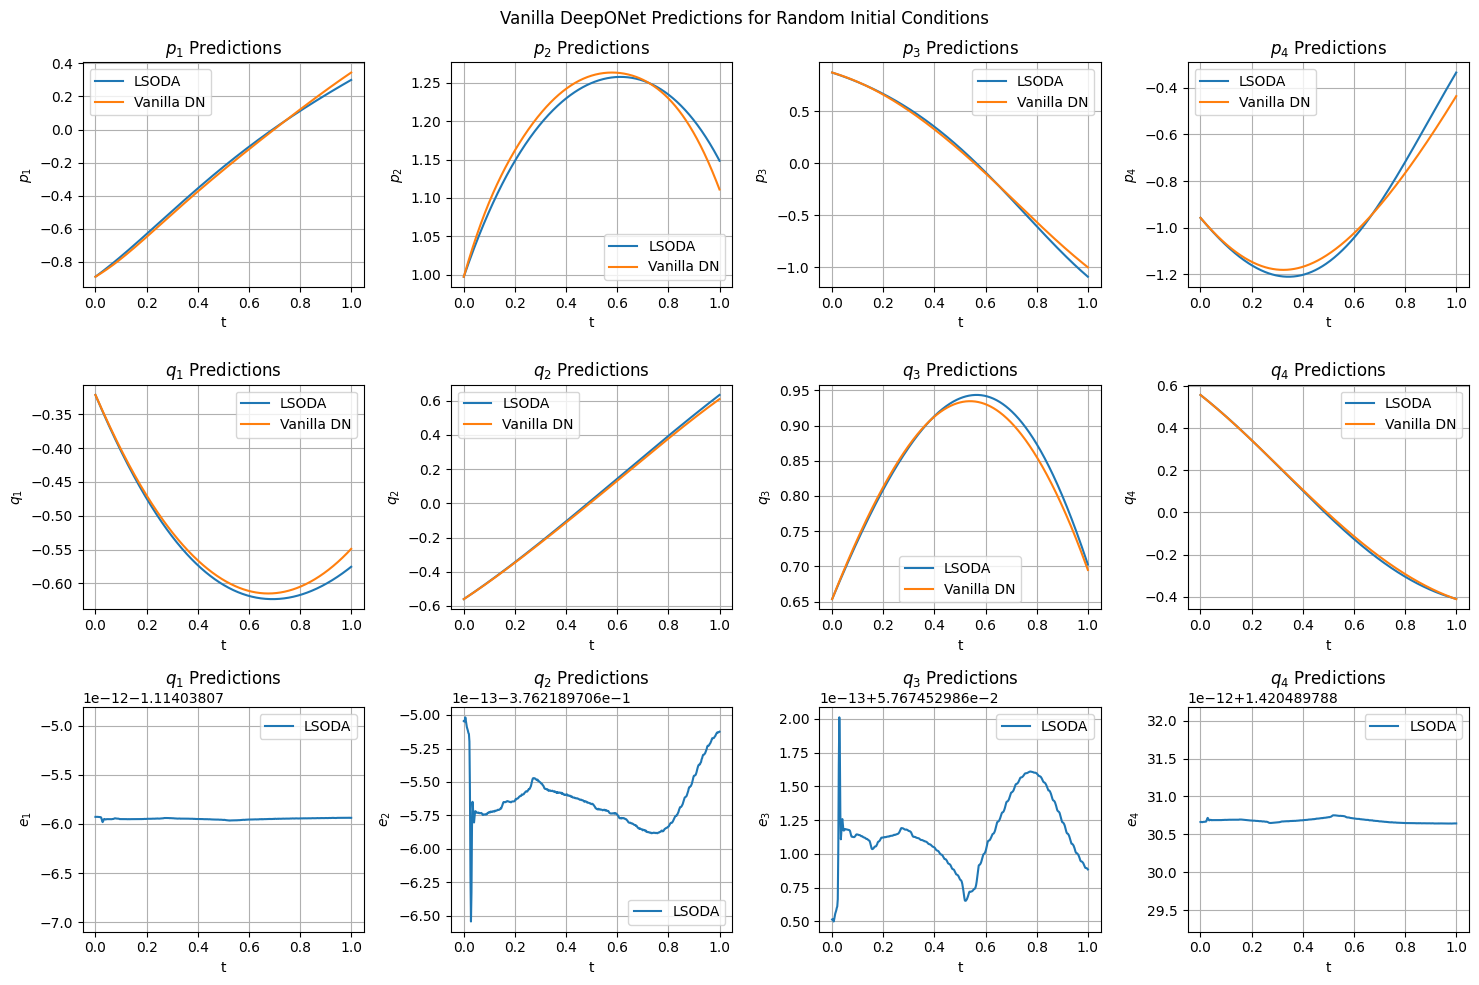

In [34]:
n = 500
t = np.linspace(t0, tfinal, n)

p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
p4_init = np.random.uniform(-1.0, 1.0, size=(1,))
q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
q4_init = np.random.uniform(-1.0, 1.0, size=(1,))
H_init = calc_H(p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init)
evals_init = calc_evals_pq(p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init)
e1_init, e2_init, e3_init, e4_init = evals_init[0], evals_init[1], evals_init[2], evals_init[3]


data_model = np.column_stack([p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init])
data_model = np.reshape(data_model, (-1,))
data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)

H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)

E_model = np.column_stack([e1_init, e2_init, e3_init, e4_init])
E_model = np.reshape(E_model, (-1,))
E_model = np.repeat(np.expand_dims(E_model, axis=0), n, axis=0)

H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        
tHE_model = np.column_stack([t, H_model, E_model])

p1 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 0, params)
p2 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 1, params)
p3 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 2, params)
p4 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 3, params)
q1 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 4, params)
q2 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 5, params)
q3 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 6, params)
q4 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 7, params)



data_rk = np.column_stack([p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t
    
sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], \
                                                         sol_rk[:, 4], sol_rk[:, 5], sol_rk[:, 6], sol_rk[:, 7]
H_rk = calc_H(p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk)
evals_rk = jax.vmap(calc_evals_pq, (0), 0)(p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk)
e1_rk, e2_rk, e3_rk, e4_rk = evals_rk[:, 0], evals_rk[:, 1], evals_rk[:, 2], evals_rk[:, 3]
print(evals_rk.shape)


fig = plt.figure(figsize=(15, 10))
fig.suptitle("Vanilla DeepONet Predictions for Random Initial Conditions")

plt.subplot(3, 4, 1)
plt.tight_layout()
plt.plot(t, p1_rk)
plt.plot(t, p1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_1$')
plt.title(r'$p_1$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])


plt.subplot(3, 4, 2)
plt.tight_layout()
plt.plot(t, p2_rk)
plt.plot(t, p2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_2$')
plt.title(r'$p_2$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

plt.subplot(3, 4, 3)
plt.tight_layout()
plt.plot(t, p3_rk)
plt.plot(t, p3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_3$')
plt.title(r'$p_3$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])


plt.subplot(3, 4, 4)
plt.tight_layout()
plt.plot(t, p4_rk)
plt.plot(t, p4)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_4$')
plt.title(r'$p_4$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])


plt.subplot(3, 4, 5)
plt.tight_layout()
plt.plot(t, q1_rk)
plt.plot(t, q1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_1$')
plt.title(r'$q_1$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])


plt.subplot(3, 4, 6)
plt.tight_layout()
plt.plot(t, q2_rk)
plt.plot(t, q2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_2$')
plt.title(r'$q_2$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

plt.subplot(3, 4, 7)
plt.tight_layout()
plt.plot(t, q3_rk)
plt.plot(t, q3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_3$')
plt.title(r'$q_3$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

plt.subplot(3, 4, 8)
plt.tight_layout()
plt.plot(t, q4_rk)
plt.plot(t, q4)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_4$')
plt.title(r'$q_4$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

plt.subplot(3, 4, 9)
plt.tight_layout()
plt.plot(t, e1_rk)
#plt.plot(t, q1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$e_1$')
plt.title(r'$q_1$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])


plt.subplot(3, 4, 10)
plt.tight_layout()
plt.plot(t, e2_rk)
#plt.plot(t, q2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$e_2$')
plt.title(r'$q_2$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

plt.subplot(3, 4, 11)
plt.tight_layout()
plt.plot(t, e3_rk)
#plt.plot(t, q3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$e_3$')
plt.title(r'$q_3$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

plt.subplot(3, 4, 12)
plt.tight_layout()
plt.plot(t, e4_rk)
#plt.plot(t, q4)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$e_4$')
plt.title(r'$q_4$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])





#fig.savefig("Toda3_vanilla_preds_5000ep.png")

In [138]:
# tree_info, shapes, params_flat = flatten_pytree(params)
# jnp.save("P_t1.0_10000_ep_Toda4", params_flat)

In [36]:
class VDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int 
  units: int

  @nn.compact
  def __call__(self, tHE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tHE.ndim == 1:
      tHE = jnp.reshape(tHE, (1,-1)) 

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:5]
    eval4_0 = tHE[:, 5:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    p1_0 = u[:, :1]
    p2_0 = u[:, 1:2]
    p3_0 = u[:, 2:3]
    p4_0 = u[:, 3:4]
    q1_0 = u[:, 4:5]
    q2_0 = u[:, 5:6]
    q3_0 = u[:, 6:7]
    q4_0 = u[:, 7:]

    u = jnp.column_stack((p1_0, p2_0, p3_0, p4_0, q1_0, q2_0, q3_0, q4_0))

    b = t_0_norm
    # b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_p2 = trunk_net[:, self.units:2*self.units]
    trunk_p3 = trunk_net[:, 2*self.units:3*self.units]
    trunk_p4 = trunk_net[:, 3*self.units:4*self.units]
    trunk_q1 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q2 = trunk_net[:, 5*self.units:6*self.units]
    trunk_q3 = trunk_net[:, 6*self.units:7*self.units]
    trunk_q4 = trunk_net[:, 7*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_p2 = branch_net[:, self.units:2*self.units]
    branch_p3 = branch_net[:, 2*self.units:3*self.units]
    branch_p4 = branch_net[:, 3*self.units:4*self.units]
    branch_q1 = branch_net[:, 4*self.units:5*self.units]
    branch_q2 = branch_net[:, 5*self.units:6*self.units]
    branch_q3 = branch_net[:, 6*self.units:7*self.units]
    branch_q4 = branch_net[:, 7*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    p4 = CombineBranches()(trunk_p4, branch_p4)  
    q1 = CombineBranches()(trunk_q1, branch_q1)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    q3 = CombineBranches()(trunk_q3, branch_q3)
    q4 = CombineBranches()(trunk_q4, branch_q4)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    p4 = HardConstraint(self.t0, self.tfinal, p4_0)([t_0, p4])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])
    q4 = HardConstraint(self.t0, self.tfinal, q4_0)([t_0, q4])
      
    p1 = jnp.reshape(p1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    p4 = jnp.reshape(p4, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    q3 = jnp.reshape(q3, (-1,))
    q4 = jnp.reshape(q4, (-1,))

    return p1, p2, p3, p4, q1, q2, q3, q4

In [37]:
@partial(jax.jit, static_argnums=(2,))
def Vvar_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Vvar(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Vvar_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Vloss(params, tHE, z):
    
    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:5]
    eval4_0 = tHE[:, 5:]
    
    p1_0 = z[:, :1]
    p2_0 = z[:, 1:2]
    p3_0 = z[:, 2:3]
    p4_0 = z[:, 3:4]
    q1_0 = z[:, 4:5]
    q2_0 = z[:, 5:6]
    q3_0 = z[:, 6:7]
    q4_0 = z[:, 7:]
    
    p1 = Vvar(tHE, z, 0, params)
    p2 = Vvar(tHE, z, 1, params)
    p3 = Vvar(tHE, z, 2, params)
    p4 = Vvar(tHE, z, 3, params)
    q1 = Vvar(tHE, z, 4, params)
    q2 = Vvar(tHE, z, 5, params)
    q3 = Vvar(tHE, z, 6, params)
    q4 = Vvar(tHE, z, 7, params)
    
    H = calc_H(p1, p2, p3, p4, q1, q2, q3, q4)
    H = jnp.reshape(H, (-1, 1))
    
    dp1_tHE = Vvar_t(tHE, z, 0, params)
    dp2_tHE = Vvar_t(tHE, z, 1, params)
    dp3_tHE = Vvar_t(tHE, z, 2, params)
    dp4_tHE = Vvar_t(tHE, z, 3, params)
    dq1_tHE = Vvar_t(tHE, z, 4, params)
    dq2_tHE = Vvar_t(tHE, z, 5, params)
    dq3_tHE = Vvar_t(tHE, z, 6, params)
    dq4_tHE = Vvar_t(tHE, z, 7, params)
        
    p1_t = dp1_tHE[:, 0]
    p2_t = dp2_tHE[:, 0]  
    p3_t = dp3_tHE[:, 0]
    p4_t = dp4_tHE[:, 0]
    q1_t = dq1_tHE[:, 0]
    q2_t = dq2_tHE[:, 0]
    q3_t = dq3_tHE[:, 0]
    q4_t = dq4_tHE[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q4 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - (jnp.exp(q2 - q3) - jnp.exp(q3 - q4))
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)

    p4_t_loss = p4_t - (jnp.exp(q3 - q4) - jnp.exp(q4 - q1))
    p4_t_loss = jnp.square(p4_t_loss)
    p4_t_loss = jnp.mean(p4_t_loss)
    
    q4_t_loss = q4_t - p4
    q4_t_loss = jnp.square(q4_t_loss)
    q4_t_loss = jnp.mean(q4_t_loss)
        
    diff_loss = p1_t_loss + p2_t_loss + p3_t_loss + p4_t_loss + q1_t_loss + q2_t_loss + q3_t_loss + q4_t_loss

    total_loss = diff_loss + H_loss

    return total_loss

@jax.jit
def Vtrain_step(params, pdes, z):
    t = pdes[:, :]
    
    return jax.value_and_grad(Vloss, has_aux = False)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def Voptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [38]:
def Vtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = Vtrain_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = Voptimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [39]:
Vdeeponet = VDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 6), 1.0)
u_init = jnp.full((10, 8), 1.0)

Vparams = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [40]:
Vparam_count = sum(x.size for x in jax.tree.leaves(Vparams))
print(param_count)

33280


In [41]:
epochs = 10000
Vparams, Vloss = Vtrain_network(Vparams, de_points, zsensors, epochs)

batch size: 100
Loss in epoch 0: 2.7983535221028912
Loss in epoch 100: 0.04655748138174883
Loss in epoch 200: 0.015766034106406073
Loss in epoch 300: 0.01062679929126354
Loss in epoch 400: 0.006510307214717581
Loss in epoch 500: 0.005468919990896805
Loss in epoch 600: 0.003576788482329997
Loss in epoch 700: 0.0031626768228486014
Loss in epoch 800: 0.0025041646579942838
Loss in epoch 900: 0.0035727231105435503
Loss in epoch 1000: 0.0016551083002844347
Loss in epoch 1100: 0.001808046278025754
Loss in epoch 1200: 0.0016771451361503268
Loss in epoch 1300: 0.0010396417932963522
Loss in epoch 1400: 0.001476749077071973
Loss in epoch 1500: 0.000979224171576932
Loss in epoch 1600: 0.0028891773205780235
Loss in epoch 1700: 0.0020892628885409575
Loss in epoch 1800: 0.0014414728985461581
Loss in epoch 1900: 0.0012444781806724232
Loss in epoch 2000: 0.0012760697394588252
Loss in epoch 2100: 0.0006448026138374621
Loss in epoch 2200: 0.000757880419327797
Loss in epoch 2300: 0.0026315086270292205
Los

In [33]:
# def derivs(a1, a2, a3, a4, b1, b2, b3, b4, e):
#     # Compute the derivative of P(lambda) with respect to lambda at lambda = e
#     c3 = -(a1 + a2 + a3 + a4)
#     c2 = (a1*a2 + a1*a3 + a1*a4 + a2*a3 + a2*a4 + a3*a4) - (b1**2 + b2**2 + b3**2 + b4**2)
#     c1 = -((a1*a2*a3 + a1*a2*a4 + a1*a3*a4 + a2*a3*a4) 
#            - (a1*b3**2 + a2*b4**2 + a3*b1**2 + a4*b2**2) 
#            + 2*b1*b2*b3*b4)
    
#     dP_dlambda = 4*e**3 + 3*c3*e**2 + 2*c2*e + c1

#     # Compute the partial derivatives of P(lambda) with respect to a_i
#     dP_da1 = (-1)*e**3 + (a2 + a3 + a4)*e**2 - (a2*a3 + a2*a4 + a3*a4)*e + (a2*a3*a4 - b3**2*a2 - b2**2*a4)
#     dP_da2 = (-1)*e**3 + (a1 + a3 + a4)*e**2 - (a1*a3 + a1*a4 + a3*a4)*e + (a1*a3*a4 - b4**2*a3 - b3**2*a1)
#     dP_da3 = (-1)*e**3 + (a1 + a2 + a4)*e**2 - (a1*a2 + a1*a4 + a2*a4)*e + (a1*a2*a4 - b1**2*a4 - b4**2*a2)
#     dP_da4 = (-1)*e**3 + (a1 + a2 + a3)*e**2 - (a1*a2 + a1*a3 + a2*a3)*e + (a1*a2*a3 - b2**2*a1 - b1**2*a3)

#     # Compute the partial derivatives of P(lambda) with respect to b_i
#     dP_db1 = (-2*b1)*e**2 + (2*b1*b3**2)*e + (-2*b1*b2**2*b3**2)
#     dP_db2 = (-2*b2)*e**2 + (2*b2*b4**2)*e + (-2*b2*b1**2*b4**2)
#     dP_db3 = (-2*b3)*e**2 + (2*b3*b1**2)*e + (-2*b3*b2**2*b1**2)
#     dP_db4 = (-2*b4)*e**2 + (2*b4*b2**2)*e + (-2*b4*b3**2*b2**2)

#     # Compute the partial derivatives of lambda with respect to a_i and b_i
#     dlambda_da1 = -dP_da1 / dP_dlambda
#     dlambda_da2 = -dP_da2 / dP_dlambda
#     dlambda_da3 = -dP_da3 / dP_dlambda
#     dlambda_da4 = -dP_da4 / dP_dlambda
#     dlambda_db1 = -dP_db1 / dP_dlambda
#     dlambda_db2 = -dP_db2 / dP_dlambda
#     dlambda_db3 = -dP_db3 / dP_dlambda
#     dlambda_db4 = -dP_db4 / dP_dlambda

#     # Return the partial derivatives as a dictionary
#     return {
#         'dlambda_da1': dlambda_da1,
#         'dlambda_da2': dlambda_da2,
#         'dlambda_da3': dlambda_da3,
#         'dlambda_da4': dlambda_da4,
#         'dlambda_db1': dlambda_db1,
#         'dlambda_db2': dlambda_db2,
#         'dlambda_db3': dlambda_db3,
#         'dlambda_db4': dlambda_db4
#     }

In [40]:
@jax.jit
def f_func_newton_eig(args, e_0) :

    args = jnp.reshape(args, (-1,))
    e_0 = jnp.reshape(e_0, (-1,))

    p1, p2, p3, p4, q1, q2, q3, q4 = args[0], args[1], args[2], args[3], args[4], args[5], args[6], args[7]
    e1_0, e2_0, e3_0, e4_0 = e_0[0], e_0[1], e_0[2], e_0[3]
    
    evals = calc_evals_pq(p1, p2, p3, p4, q1, q2, q3, q4)

    e1, e2, e3, e4 = evals[0], evals[1], evals[2], evals[3]

    f1 = e1 - e1_0
    f2 = e2 - e2_0
    f3 = e3 - e3_0
    f4 = e4 - e4_0

    # f = jnp.array([[f1], [f2], [f3], [f4]])
    # f = jnp.reshape(f, (4, 1))

    f_val = f1**2 + f2**2 + f3**2 + f4**2
    f = jnp.array([[f_val]])
    f = jnp.reshape(f, (1, 1))

    return f
    
@jax.jit
def get_derivs_newton_eig(args, e_0, e) :

    a1, a2, a3, a4, b1, b2, b3, b4 = args[0], args[1], args[2], args[3], args[4], args[5], args[6], args[7]
    

    c4 = 1

    c3 = -(a1 + a2 + a3 + a4)  
    
    c2 = a1 * a2 + a1 * a3 + a1 * a4 + a2 * a3 + a2 * a4 + a3 * a4 - b1**2 - b2**2 - b3**2 - b4**2
    
    c1 = -a1 * a2 * a3 - a1 * a2 * a4 - a1 * a3 * a4 - a2 * a3 * a4 + a1 * b2**2 + a1 * b3**2 \
         + a2 * b3**2 + a2 * b4**2 + a3 * b1**2 + a3 * b4**2 + a4 * b1**2 + a4 * b2**2
    
    c0 = a1 * a2 * a3 * a4 - a1 * a2 * b3**2 - a1 * a4 * b2**2 - a2 * a3 * b4**2 - a3 * a4 * b1**2 \
        + b1**2 * b3**2 - 2 * b1 * b2 * b3 * b4 + b2**2 * b4**2
    
    
    dP_e = 4*e**3 + 3*c3*e**2 + 2*c2*e + c1

    dP_a1 = -e**3 + (a2 + a3 + a4) * e**2 - (a2 * a3 + a2 * a4 + a3 * a4 - b2**2 - b3**2) * e \
              + a2 * a3 * a4 - a2 * b3**2 - a4 * b2**2
    dP_a2 = -e**3 + (a1 + a3 + a4) * e**2 - (a1 * a3 + a1 * a4 + a3 * a4 - b3**2 - b4**2) * e \
              + a1 * a3 * a4 - a1 * b3**2 - a3 * b4**2
    dP_a3 = -e**3 + (a1 + a2 + a4) * e**2 - (a1 * a2 + a1 * a4 + a2 * a4 - b1**2 - b4**2) * e \
              + a1 * a2 * a4 - a2 * b4**2 - a4 * b1**2
    dP_a4 = -e**3 + (a1 + a2 + a3) * e**2 - (a1 * a2 + a1 * a3 + a2 * a3 - b1**2 - b2**2) * e \
              + a1 * a2 * a3 - a1 * b2**2 - a3 * b1**2

    dP_b1 = -2 * b1 * e**2 + 2 * b1 * (a3 + a4) * e - 2 * b1 * a3 * a4 \
              + 2 * b1 * b3**2 - 2 * b2 * b3 * b4
    dP_b2 = -2 * b2 * e**2 + 2 * b2 * (a1 + a4) * e - 2 * b2 * a1 * a4 \
              + 2 * b2 * b4**2 - 2 * b1 * b3 * b4
    dP_b3 = -2 * b3 * e**2 + 2 * b3 * (a1 + a2) * e - 2 * b3 * a1 * a2 \
              + 2 * b3 * b1**2 - 2 * b1 * b2 * b4
    dP_b4 = -2 * b4 * e**2 + 2 * b4 * (a2 + a3) * e - 2 * b4 * a2 * a3 \
              + 2 * b4 * b2**2 - 2 * b1 * b2 * b3

    de_a1 = -dP_a1 / dP_e
    de_a2 = -dP_a2 / dP_e
    de_a3 = -dP_a3 / dP_e
    de_a4 = -dP_a4 / dP_e
    de_b1 = -dP_b1 / dP_e
    de_b2 = -dP_b2 / dP_e
    de_b3 = -dP_b3 / dP_e
    de_b4 = -dP_b4 / dP_e

    df_a1 = de_a1
    df_a2 = de_a2
    df_a3 = de_a3
    df_a4 = de_a4
    df_b1 = de_b1
    df_b2 = de_b2
    df_b3 = de_b3
    df_b4 = de_b4

    df_x = (df_a1, df_a2, df_a3, df_a4, df_b1, df_b2, df_b3, df_b4)

    return df_x


@jax.jit
def gradf_func_newton_eig(args, e_0) :

    e_0 = jnp.reshape(e_0, (-1,))

    p1, p2, p3, p4, q1, q2, q3, q4 = args[0], args[1], args[2], args[3], args[4], args[5], args[6], args[7]
    e1_0, e2_0, e3_0, e4_0 = e_0[0], e_0[1], e_0[2], e_0[3]

    a1, a2, a3, a4, b1, b2, b3, b4 = calc_ab(p1, p2, p3, p4, q1, q2, q3, q4)
    args_new = (a1, a2, a3, a4, b1, b2, b3, b4)
    
    evals = calc_evals_pq(p1, p2, p3, p4, q1, q2, q3, q4)
    
    e1, e2, e3, e4 = evals[0], evals[1], evals[2], evals[3]
 
    df1_a1, df1_a2, df1_a3, df1_a4, df1_b1, df1_b2, df1_b3, df1_b4 = get_derivs_newton_eig(args_new, e1_0, e1)
    df2_a1, df2_a2, df2_a3, df2_a4, df2_b1, df2_b2, df2_b3, df2_b4 = get_derivs_newton_eig(args_new, e2_0, e2)
    df3_a1, df3_a2, df3_a3, df3_a4, df3_b1, df3_b2, df3_b3, df3_b4 = get_derivs_newton_eig(args_new, e3_0, e3)
    df4_a1, df4_a2, df4_a3, df4_a4, df4_b1, df4_b2, df4_b3, df4_b4 = get_derivs_newton_eig(args_new, e4_0, e4)

    df1_p1, df2_p1, df3_p1, df4_p1 = df1_a1*-0.5, df2_a1*-0.5, df3_a1*-0.5, df4_a1*-0.5
    df1_p2, df2_p2, df3_p2, df4_p2 = df1_a2*-0.5, df2_a2*-0.5, df3_a2*-0.5, df4_a2*-0.5
    df1_p3, df2_p3, df3_p3, df4_p3 = df1_a3*-0.5, df2_a3*-0.5, df3_a3*-0.5, df4_a3*-0.5
    df1_p4, df2_p4, df3_p4, df4_p4 = df1_a4*-0.5, df2_a4*-0.5, df3_a4*-0.5, df4_a4*-0.5

    df1_q1 = df1_b1*0.5*b1 + df1_b4*-0.5*b4
    df2_q1 = df2_b1*0.5*b1 + df2_b4*-0.5*b4
    df3_q1 = df3_b1*0.5*b1 + df3_b4*-0.5*b4
    df4_q1 = df4_b1*0.5*b1 + df4_b4*-0.5*b4

    df1_q2 = df1_b1*-0.5*b1 + df1_b2*0.5*b2
    df2_q2 = df2_b1*-0.5*b1 + df2_b2*0.5*b2
    df3_q2 = df3_b1*-0.5*b1 + df3_b2*0.5*b2
    df4_q2 = df4_b1*-0.5*b1 + df4_b2*0.5*b2

    df1_q3 = df1_b2*-0.5*b2 + df1_b3*0.5*b3
    df2_q3 = df2_b2*-0.5*b2 + df2_b3*0.5*b3
    df3_q3 = df3_b2*-0.5*b2 + df3_b3*0.5*b3
    df4_q3 = df4_b2*-0.5*b2 + df4_b3*0.5*b3

    df1_q4 = df1_b3*-0.5*b3 + df1_b4*0.5*b4
    df2_q4 = df2_b3*-0.5*b3 + df2_b4*0.5*b4
    df3_q4 = df3_b3*-0.5*b3 + df3_b4*0.5*b4
    df4_q4 = df4_b3*-0.5*b3 + df4_b4*0.5*b4

    df_p1 = 2 * (e1 - e1_0) * df1_p1 + 2 * (e2 - e2_0) * df2_p1 + 2 * (e3 - e3_0) * df3_p1 + 2 * (e4 - e4_0) * df4_p1
    df_p2 = 2 * (e1 - e1_0) * df1_p2 + 2 * (e2 - e2_0) * df2_p2 + 2 * (e3 - e3_0) * df3_p2 + 2 * (e4 - e4_0) * df4_p2
    df_p3 = 2 * (e1 - e1_0) * df1_p3 + 2 * (e2 - e2_0) * df2_p3 + 2 * (e3 - e3_0) * df3_p3 + 2 * (e4 - e4_0) * df4_p3
    df_p4 = 2 * (e1 - e1_0) * df1_p4 + 2 * (e2 - e2_0) * df2_p4 + 2 * (e3 - e3_0) * df3_p4 + 2 * (e4 - e4_0) * df4_p4
    df_q1 = 2 * (e1 - e1_0) * df1_q1 + 2 * (e2 - e2_0) * df2_q1 + 2 * (e3 - e3_0) * df3_q1 + 2 * (e4 - e4_0) * df4_q1
    df_q2 = 2 * (e1 - e1_0) * df1_q2 + 2 * (e2 - e2_0) * df2_q2 + 2 * (e3 - e3_0) * df3_q2 + 2 * (e4 - e4_0) * df4_q2
    df_q3 = 2 * (e1 - e1_0) * df1_q3 + 2 * (e2 - e2_0) * df2_q3 + 2 * (e3 - e3_0) * df3_q3 + 2 * (e4 - e4_0) * df4_q3
    df_q4 = 2 * (e1 - e1_0) * df1_q4 + 2 * (e2 - e2_0) * df2_q4 + 2 * (e3 - e3_0) * df3_q4 + 2 * (e4 - e4_0) * df4_q4

# Output the results

    
    # gradf = jnp.array([[df1_p1, df1_p2, df1_p3, df1_p4, df1_q1, df1_q2, df1_q3, df1_q4],
    #                    [df2_p1, df2_p2, df2_p3, df2_p4, df2_q1, df2_q2, df2_q3, df2_q4],
    #                    [df3_p1, df3_p2, df3_p3, df3_p4, df3_q1, df3_q2, df3_q3, df3_q4],
    #                    [df4_p1, df4_p2, df4_p3, df4_p4, df4_q1, df4_q2, df4_q3, df4_q4]])

    

    # gradf = jnp.reshape(gradf, (4, 8))

    gradf = jnp.array([[df_p1, df_p2, df_p3, df_p4, df_q1, df_q2, df_q3, df_q4]])
    gradf = jnp.reshape(gradf, (1, 8))
                    
    return gradf
    
#@jax.jit
def newtons_eig_root(x, e_0) :

    iter_num = 0

    e_0 = jnp.reshape(e_0, (-1, 1))

    while iter_num < 1 :

        x = jnp.reshape(x, (-1, 1))
        
        F = f_func_newton_eig(x, e_0)
        J = gradf_func_newton_eig(x, e_0)
        J_norm = jnp.linalg.norm(J)
        J_inv = (1/J_norm)*J.T
        
        #J_inv = jnp.linalg.pinv(J)
        #print(x.shape, F.shape, J.shape, J_inv.shape)

        x = x - J_inv@F

        iter_num = iter_num + 1

    return x

    # """
    # Newton's method for root finding in an underdetermined system using lax.scan.
    # """
    # # Reshape inputs once outside the loop
    # x = jnp.reshape(x, (-1, 1))  # 8x1
    # e_0 = jnp.reshape(e_0, (-1, 1))  # 4x1

    # def body_fn(x, _):
    #     """
    #     Body function for Newton's method iteration.
    #     """
    #     F = f_func_newton_eig(x, e_0)  # 4x1
    #     J = gradf_func_newton_eig(x, e_0)  # 4x8

    #     # Solve J J^T alpha = F for alpha (4x4 system)
    #     J_J_T = J @ J.T  # 4x4
    #     alpha = jnp.linalg.solve(J_J_T + 1e-8 * jnp.eye(J_J_T.shape[0]), F)  # 4x1

    #     # Compute delta_x = J^T alpha (8x1)
    #     delta_x = J.T @ alpha  # 8x1

    #     # Update x
    #     x = x - delta_x
    #     return x, None  # Return updated state and None (no output)

    # # Run the loop using lax.scan
    # x_final, _ = lax.scan(body_fn, x, None, length=5)
    # return x_final

    # # Run the loop using lax.fori_loop
    # x_final = lax.fori_loop(0, 5, body_fn, x)
    # return x_final

@jax.jit
def find_min_newton_eig(x, e_0) :

    return jnp.squeeze(jax.vmap(newtons_eig_root, (0, 0))(x, e_0))

In [41]:
# @jax.jit
# def f_func_newton_eig(args, e_0) :

#     args = jnp.reshape(args, (-1,))
#     e_0 = jnp.reshape(e_0, (-1,))

#     p1, p2, p3, p4, q1, q2, q3, q4 = args[0], args[1], args[2], args[3], args[4], args[5], args[6], args[7]
#     e1_0, e2_0, e3_0, e4_0 = e_0[0], e_0[1], e_0[2], e_0[3]
    
#     evals = calc_evals_pq(p1, p2, p3, p4, q1, q2, q3, q4)

#     e1, e2, e3, e4 = evals[0], evals[1], evals[2], evals[3]

#     f1 = (e1 - e1_0)**2
#     f2 = (e2 - e2_0)**2
#     f3 = (e3 - e3_0)**2
#     f4 = (e4 - e4_0)**2

#     f_val = f1 + f2 + f3 + f4

#     f = jnp.array([[f_val]])
#     f = jnp.reshape(f, (1,))

#     return f
    
# @jax.jit
# def get_derivs_newton_eig(args, e_0, e) :

#     a1, a2, a3, a4, b1, b2, b3, b4 = args[0], args[1], args[2], args[3], args[4], args[5], args[6], args[7]
    

#     c4 = 1

#     c3 = -(a1 + a2 + a3 + a4)  
    
#     c2 = a1 * a2 + a1 * a3 + a1 * a4 + a2 * a3 + a2 * a4 + a3 * a4 - b1**2 - b2**2 - b3**2 - b4**2
    
#     c1 = -a1 * a2 * a3 - a1 * a2 * a4 - a1 * a3 * a4 - a2 * a3 * a4 + a1 * b2**2 + a1 * b3**2 \
#          + a2 * b3**2 + a2 * b4**2 + a3 * b1**2 + a3 * b4**2 + a4 * b1**2 + a4 * b2**2
    
#     c0 = a1 * a2 * a3 * a4 - a1 * a2 * b3**2 - a1 * a4 * b2**2 - a2 * a3 * b4**2 - a3 * a4 * b1**2 \
#         + b1**2 * b3**2 - 2 * b1 * b2 * b3 * b4 + b2**2 * b4**2
    
    
#     dP_e = 4*e**3 + 3*c3*e**2 + 2*c2*e + c1

#     dP_a1 = -e**3 + (a2 + a3 + a4) * e**2 - (a2 * a3 + a2 * a4 + a3 * a4 - b2**2 - b3**2) * e \
#               + a2 * a3 * a4 - a2 * b3**2 - a4 * b2**2
#     dP_a2 = -e**3 + (a1 + a3 + a4) * e**2 - (a1 * a3 + a1 * a4 + a3 * a4 - b3**2 - b4**2) * e \
#               + a1 * a3 * a4 - a1 * b3**2 - a3 * b4**2
#     dP_a3 = -e**3 + (a1 + a2 + a4) * e**2 - (a1 * a2 + a1 * a4 + a2 * a4 - b1**2 - b4**2) * e \
#               + a1 * a2 * a4 - a2 * b4**2 - a4 * b1**2
#     dP_a4 = -e**3 + (a1 + a2 + a3) * e**2 - (a1 * a2 + a1 * a3 + a2 * a3 - b1**2 - b2**2) * e \
#               + a1 * a2 * a3 - a1 * b2**2 - a3 * b1**2

#     dP_b1 = -2 * b1 * e**2 + 2 * b1 * (a3 + a4) * e - 2 * b1 * a3 * a4 \
#               + 2 * b1 * b3**2 - 2 * b2 * b3 * b4
#     dP_b2 = -2 * b2 * e**2 + 2 * b2 * (a1 + a4) * e - 2 * b2 * a1 * a4 \
#               + 2 * b2 * b4**2 - 2 * b1 * b3 * b4
#     dP_b3 = -2 * b3 * e**2 + 2 * b3 * (a1 + a2) * e - 2 * b3 * a1 * a2 \
#               + 2 * b3 * b1**2 - 2 * b1 * b2 * b4
#     dP_b4 = -2 * b4 * e**2 + 2 * b4 * (a2 + a3) * e - 2 * b4 * a2 * a3 \
#               + 2 * b4 * b2**2 - 2 * b1 * b2 * b3

#     de_a1 = -dP_a1 / dP_e
#     de_a2 = -dP_a2 / dP_e
#     de_a3 = -dP_a3 / dP_e
#     de_a4 = -dP_a4 / dP_e
#     de_b1 = -dP_b1 / dP_e
#     de_b2 = -dP_b2 / dP_e
#     de_b3 = -dP_b3 / dP_e
#     de_b4 = -dP_b4 / dP_e

#     df_a1 = de_a1
#     df_a2 = de_a2
#     df_a3 = de_a3
#     df_a4 = de_a4
#     df_b1 = de_b1
#     df_b2 = de_b2
#     df_b3 = de_b3
#     df_b4 = de_b4

#     df_x = (df_a1, df_a2, df_a3, df_a4, df_b1, df_b2, df_b3, df_b4)

#     return df_x


# @jax.jit
# def gradf_func_newton_eig(args, e_0) :

#     args = jnp.reshape(args, (-1,))
#     e_0 = jnp.reshape(e_0, (-1,))

#     p1, p2, p3, p4, q1, q2, q3, q4 = args[0], args[1], args[2], args[3], args[4], args[5], args[6], args[7]
#     e1_0, e2_0, e3_0, e4_0 = e_0[0], e_0[1], e_0[2], e_0[3]

#     a1, a2, a3, a4, b1, b2, b3, b4 = calc_ab(p1, p2, p3, p4, q1, q2, q3, q4)
#     args_new = (a1, a2, a3, a4, b1, b2, b3, b4)
    
#     evals = calc_evals_pq(p1, p2, p3, p4, q1, q2, q3, q4)
    
#     e1, e2, e3, e4 = evals[0], evals[1], evals[2], evals[3]
 
#     df1_a1, df1_a2, df1_a3, df1_a4, df1_b1, df1_b2, df1_b3, df1_b4 = get_derivs_newton_eig(args_new, e1_0, e1)
#     df2_a1, df2_a2, df2_a3, df2_a4, df2_b1, df2_b2, df2_b3, df2_b4 = get_derivs_newton_eig(args_new, e2_0, e2)
#     df3_a1, df3_a2, df3_a3, df3_a4, df3_b1, df3_b2, df3_b3, df3_b4 = get_derivs_newton_eig(args_new, e3_0, e3)
#     df4_a1, df4_a2, df4_a3, df4_a4, df4_b1, df4_b2, df4_b3, df4_b4 = get_derivs_newton_eig(args_new, e4_0, e4)


#     df1_p1, df2_p1, df3_p1, df4_p1 = df1_a1*-0.5, df2_a1*-0.5, df3_a1*-0.5, df4_a1*-0.5
#     df1_p2, df2_p2, df3_p2, df4_p2 = df1_a2*-0.5, df2_a2*-0.5, df3_a2*-0.5, df4_a2*-0.5
#     df1_p3, df2_p3, df3_p3, df4_p3 = df1_a3*-0.5, df2_a3*-0.5, df3_a3*-0.5, df4_a3*-0.5
#     df1_p4, df2_p4, df3_p4, df4_p4 = df1_a4*-0.5, df2_a4*-0.5, df3_a4*-0.5, df4_a4*-0.5

#     df1_q1 = df1_b1*0.5*b1 + df1_b4*-0.5*b4
#     df2_q1 = df2_b1*0.5*b1 + df2_b4*-0.5*b4
#     df3_q1 = df3_b1*0.5*b1 + df3_b4*-0.5*b4
#     df4_q1 = df4_b1*0.5*b1 + df4_b4*-0.5*b4

#     df1_q2 = df1_b1*-0.5*b1 + df1_b2*0.5*b2
#     df2_q2 = df2_b1*-0.5*b1 + df2_b2*0.5*b2
#     df3_q2 = df3_b1*-0.5*b1 + df3_b2*0.5*b2
#     df4_q2 = df4_b1*-0.5*b1 + df4_b2*0.5*b2

#     df1_q3 = df1_b2*-0.5*b2 + df1_b3*0.5*b3
#     df2_q3 = df2_b2*-0.5*b2 + df2_b3*0.5*b3
#     df3_q3 = df3_b2*-0.5*b2 + df3_b3*0.5*b3
#     df4_q3 = df4_b2*-0.5*b2 + df4_b3*0.5*b3

#     df1_q4 = df1_b3*-0.5*b3 + df1_b4*0.5*b4
#     df2_q4 = df2_b3*-0.5*b3 + df2_b4*0.5*b4
#     df3_q4 = df3_b3*-0.5*b3 + df3_b4*0.5*b4
#     df4_q4 = df4_b3*-0.5*b3 + df4_b4*0.5*b4


#     df_p1 = 2*(e1 - e1_0)*df1_p1 + 2*(e2 - e2_0)*df2_p1 + 2*(e3 - e3_0)*df3_p1 + 2*(e4 - e4_0)*df4_p1
#     df_p2 = 2*(e1 - e1_0)*df1_p2 + 2*(e2 - e2_0)*df2_p2 + 2*(e3 - e3_0)*df3_p2 + 2*(e4 - e4_0)*df4_p2
#     df_p3 = 2*(e1 - e1_0)*df1_p3 + 2*(e2 - e2_0)*df2_p3 + 2*(e3 - e3_0)*df3_p3 + 2*(e4 - e4_0)*df4_p3
#     df_p4 = 2*(e1 - e1_0)*df1_p4 + 2*(e2 - e2_0)*df2_p4 + 2*(e3 - e3_0)*df3_p4 + 2*(e4 - e4_0)*df4_p4
#     df_q1 = 2*(e1 - e1_0)*df1_q1 + 2*(e2 - e2_0)*df2_q1 + 2*(e3 - e3_0)*df3_q1 + 2*(e4 - e4_0)*df4_q1
#     df_q2 = 2*(e1 - e1_0)*df1_q2 + 2*(e2 - e2_0)*df2_q2 + 2*(e3 - e3_0)*df3_q2 + 2*(e4 - e4_0)*df4_q2
#     df_q3 = 2*(e1 - e1_0)*df1_q3 + 2*(e2 - e2_0)*df2_q3 + 2*(e3 - e3_0)*df3_q3 + 2*(e4 - e4_0)*df4_q3
#     df_q4 = 2*(e1 - e1_0)*df1_q4 + 2*(e2 - e2_0)*df2_q4 + 2*(e3 - e3_0)*df3_q4 + 2*(e4 - e4_0)*df4_q4
    
#     gradf = jnp.array([[df_p1, df_p2, df_p3, df_p4, df_q1, df_q2, df_q3, df_q4]])

#     gradf = jnp.reshape(gradf, (8,))
                    
#     return gradf
    
# # @jax.jit
# # def newtons_eig_root(x, e_0) :

# #     iter_num = 0

# #     e_0 = jnp.reshape(e_0, (-1, 1))

# #     while iter_num < 5 :

# #         x = jnp.reshape(x, (-1, 1))
        
# #         F = f_func_newton_eig(x, e_0)
# #         J = gradf_func_newton_eig(x, e_0)
# #         J_inv = jnp.linalg.pinv(J)
# #         # J_inv = J.T@jnp.linalg.inv(J@J.T)

# #         print(x.shape, F.shape, J.shape, J_inv.shape)

# #         x = x - J_inv@F

# #         iter_num = iter_num + 1

# #     return x


# #@jax.jit
# @jax.jit
# def lbfgs_optimize(x_init, e_0, max_iter=1, memory_size=1, step_size=0.01, tol=1e-6):
#     """
#     L-BFGS optimization algorithm for minimizing the objective function `f_func_newton_eig`.
    
#     Args:
#         x_init: Initial guess for the parameters.
#         e_0: Target eigenvalues.
#         max_iter: Maximum number of iterations.
#         memory_size: Number of past updates to store for L-BFGS.
#         step_size: Learning rate.
#         tol: Tolerance for convergence.
    
#     Returns:
#         Optimized parameters.
#     """
#     def body_fn(state, _):
#         x, grad, s_list, y_list, rho_list = state

#         # Compute L-BFGS direction
#         q = grad
#         alpha_list = []
#         for s, y, rho in zip(reversed(s_list), reversed(y_list), reversed(rho_list)):
#             alpha = rho * jnp.dot(s, q)
#             q = q - alpha * y
#             alpha_list.append(alpha)

#         r = q  # Initial Hessian approximation is identity (H0 = 1.0)
#         for s, y, rho, alpha in zip(s_list, y_list, rho_list, reversed(alpha_list)):
#             beta = rho * jnp.dot(y, r)
#             r = r + s * (alpha - beta)

#         direction = -r  # L-BFGS search direction

#         # Update parameters
#         x_new = x + step_size * direction
#         grad_new = gradf_func_newton_eig(x_new, e_0)
#         grad_new = jnp.reshape(grad_new, (-1,))  # Reshape gradient to (8,)

#         # Update L-BFGS history
#         s = x_new - x
#         y = grad_new - grad
#         rho = 1.0 / jnp.dot(y, s)

#         # Maintain fixed-size memory
#         s_list = jnp.concatenate([s_list[1:], jnp.expand_dims(s, axis=0)], axis=0)
#         y_list = jnp.concatenate([y_list[1:], jnp.expand_dims(y, axis=0)], axis=0)
#         rho_list = jnp.concatenate([rho_list[1:], jnp.expand_dims(rho, axis=0)], axis=0)

#         # Update state
#         state = (x_new, grad_new, s_list, y_list, rho_list)
#         return state, None  # Return state and None (no carry output)

#     # Initialize state with fixed shapes
#     grad_init = gradf_func_newton_eig(x_init, e_0)
#     grad_init = jnp.reshape(grad_init, (-1,))  # Reshape gradient to (8,)
#     s_list_init = jnp.zeros((memory_size, x_init.shape[0]))  # Fixed shape (memory_size, 8)
#     y_list_init = jnp.zeros((memory_size, x_init.shape[0]))  # Fixed shape (memory_size, 8)
#     rho_list_init = jnp.zeros((memory_size,))  # Fixed shape (memory_size,)
#     state_init = (x_init, grad_init, s_list_init, y_list_init, rho_list_init)

#     # Run L-BFGS optimization using lax.scan
#     state_final, _ = lax.scan(body_fn, state_init, None, length=max_iter)
#     x_opt, _, _, _, _ = state_final

#     return x_opt

# # # Example usage
# # x_init = jnp.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])  # Initial guess (shape: (8,))
# # e_0 = jnp.array([1.0, 2.0, 3.0, 4.0])  # Target eigenvalues (shape: (4,))

# # # Run Adam optimization
# # result = lbfgs_optimize(x_init, e_0)

# # print("Optimized parameters:", result)

# #@jax.jit
# def find_min_newton_eig(x, e_0) :

#     return jnp.squeeze(jax.vmap(lbfgs_optimize, (0, 0))(x, e_0))

In [42]:
@jax.jit
def f_func(args, EV_0) :

    f = f_func_newton_eig(args, EV_0)
    f = jnp.reshape(f, (1, 1))

    return f


@jax.jit
def gradf_func(args, EV_0) :

    gradf = gradf_func_newton_eig(args, EV_0)
    gradf = jnp.reshape(gradf, (8, 1))

    return gradf


@jax.jit
def find_rec(x):
    
    x = x + jnp.finfo(jnp.float64).eps
    
    return 1/x


@jax.jit
def wolfe_conds(args):

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, EV_0, iter = args

    c1 = 1e-4

    cond = next_f - curr_f - c1*alpha*(curr_grad.T@p)

    cond_bool = jax.lax.cond(cond[0][0] > 0.0 , lambda x: True, lambda x: False, None)
    final_bool = cond_bool
    
    return final_bool


@jax.jit
def update_alpha(args) :

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, EV_0, iter = args

    alpha = alpha*0.1
    iter = iter + 1
        
    next_x = curr_x + alpha*p
    next_f = f_func(next_x, EV_0)
    next_grad = gradf_func(next_x, EV_0) 
   
    return (alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, EV_0, iter)


@jax.jit
def BFGS(x, EV_0) :

    iter_num = 0
    init_iter = 0
    alpha = 1.0
    I_3 = jnp.identity(8, dtype = jnp.float64)
    B_0_inv = jnp.identity(8, dtype = jnp.float64)

    x_0 = x
    x_0 = jnp.reshape(x_0, (-1, 1))

    D_0 = f_func(x_0, EV_0)
    gradD_0 = gradf_func(x_0, EV_0)

    p = -(B_0_inv@gradD_0)

    pot_x = x_0 + alpha*p
    pot_D = f_func(pot_x, EV_0)
    pot_gradD = gradf_func(pot_x, EV_0)

    init_args = (alpha, x_0, D_0, gradD_0, pot_x, pot_D, pot_gradD, p, EV_0, init_iter)
    
    step, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

    x_1 = x_0 + step*p

    while iter_num < 2:

        delta_x = x_1 - x_0

        D_1 = f_func(x_1, EV_0)
        gradD_1 = gradf_func(x_1, EV_0)

        y = gradD_1 - gradD_0       

        y_T_delta_x = y.T@delta_x
        y_T_delta_x_rec = find_rec(y_T_delta_x)
        
        B_1_inv = ((I_3 - (y_T_delta_x_rec*(delta_x@y.T)))@B_0_inv@(I_3 - (y_T_delta_x_rec*(y@delta_x.T)))) + (y_T_delta_x_rec*(delta_x@delta_x.T))   
        p = -(B_1_inv@gradD_1)
        
        pot_x = x_1 + alpha*p
        pot_D = f_func(pot_x, EV_0)
        pot_gradD = gradf_func(pot_x, EV_0) 
                  
        init_args = (alpha, x_1, D_1, gradD_1, pot_x, pot_D, pot_gradD, p, EV_0, init_iter)

        step, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

        x_temp = x_1 + step*p

        x_0 = x_1
        x_1 = x_temp

        D_0 = D_1
        gradD_0 = gradD_1

        B_0_inv = B_1_inv
        
        iter_num = iter_num + 1

    A = x_1[0]
    F = x_1[1]
    G = x_1[2]

    A = jnp.reshape(A, (-1, ))[0]
    F = jnp.reshape(F, (-1, ))[0]
    G = jnp.reshape(G, (-1, ))[0]


    return x_1

@jax.jit
def find_min_bfgs(x, EV_0) :


    return jnp.squeeze(jax.vmap(BFGS, (0, 0), 0)(x, EV_0))

In [43]:
# x_test = jnp.array([[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0], [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]])
# EV_test = jnp.array([[4.0, 5.0, 6.0, 7.0], [4.0, 5.0, 6.0, 7.0]])

# test = find_min_bfgs(x_test, EV_test)
# print(test.shape, test)

In [44]:
x_test = jnp.array([[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0], [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]])
e_test = jnp.array([[1.0, 2.0, 3.0, 4.0], [1.0, 2.0, 3.0, 4.0]])

print(calc_H(1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0))

sol_newton_eig = find_min_newton_eig(x_test, e_test)

p1N, p2N, p3N, p4N, q1N, q2N, q3N, q4N = sol_newton_eig[0, 0], sol_newton_eig[0, 1], sol_newton_eig[0, 2], sol_newton_eig[0, 3], \
                                         sol_newton_eig[0, 4], sol_newton_eig[0, 5], sol_newton_eig[0, 6], sol_newton_eig[0, 7]

print(p1N, p2N, p3N, p4N, q1N, q2N, q3N, q4N, calc_H(p1N, p2N, p3N, p4N, q1N, q2N, q3N, q4N))

36.18917524670199
-21.004158748397117 -22.366166088762668 -20.23074705481901 -21.59275439518457 28.273000905705917 6.939697087691651 6.060302912308352 -15.273000905705924 3681003514.2024984


In [44]:
@jax.jit
def f_func_newton_H(args, H_0) :

    args = jnp.reshape(args, (-1,))
    H_0 = jnp.reshape(H_0, (-1,))

    p1, p2, p3, p4, q1, q2, q3, q4 = args[0], args[1], args[2], args[3], args[4], args[5], args[6], args[7]
    H_0 = H_0[0]
    
    H = calc_H(p1, p2, p3, p4, q1, q2, q3, q4)

    f_val = H - H_0
    
    f = jnp.array([[f_val]])

    return f
    
@jax.jit
def gradf_func_newton_H(args, H_0) :

    args = jnp.reshape(args, (-1,))
    H_0 = jnp.reshape(H_0, (-1,))

    p1, p2, p3, p4, q1, q2, q3, q4 = args[0], args[1], args[2], args[3], args[4], args[5], args[6], args[7]
    H_0 = H_0[0]    

    dH_p1 = p1
    dH_p2 = p2
    dH_p3 = p3
    dH_p4 = p4
    dH_q1 = jnp.exp(q1 - q2) - jnp.exp(q4 - q1)
    dH_q2 = -jnp.exp(q1 - q2) + jnp.exp(q2 - q3)
    dH_q3 = -jnp.exp(q2 - q3) + jnp.exp(q3 - q4)
    dH_q4 = -jnp.exp(q3 - q4) + jnp.exp(q4 - q1)

    df_p1 = dH_p1
    df_p2 = dH_p2
    df_p3 = dH_p3
    df_p4 = dH_p4
    df_q1 = dH_q1
    df_q2 = dH_q2
    df_q3 = dH_q3
    df_q4 = dH_q4

    grad_f = jnp.array([[df_p1, df_p2, df_p3, df_p4, df_q1, df_q2, df_q3, df_q4]])

    return grad_f


@jax.jit
def newtons_H_root(x, H_0) :

    iter_num = 0

    H_0 = jnp.reshape(H_0, (-1, 1))

    while iter_num < 1 :

        x = jnp.reshape(x, (-1, 1))
        
        F = f_func_newton_H(x, H_0)
        J = gradf_func_newton_H(x, H_0)
        J_inv = jnp.linalg.pinv(J)

        x = x - J_inv@F

        iter_num = iter_num + 1

    return x

@jax.jit
def find_min_newton_H(x, H_0) :

    return jnp.squeeze(jax.vmap(newtons_H_root, (0, 0), 0)(x, H_0))

In [45]:
# x_test = jnp.array([[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0], [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]])
# H_test = jnp.array([[1.0], [1.0]])

# print(calc_H(1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0))

# sol_newton_H = find_min_newton_H(x_test, H_test)

# p1N, p2N, p3N, p4N, q1N, q2N, q3N, q4N = sol_newton_H[0, 0], sol_newton_H[0, 1], sol_newton_H[0, 2], sol_newton_H[0, 3], \
#                                          sol_newton_H[0, 4], sol_newton_H[0, 5], sol_newton_H[0, 6], sol_newton_H[0, 7]

# print(p1N, p2N, p3N, p4N, q1N, q2N, q3N, q4N, calc_H(p1N, p2N, p3N, p4N, q1N, q2N, q3N, q4N))

36.18917524670199
0.9564259610264453 1.9128519220528906 2.8692778830793357 3.825703844105781 5.859177975588578 6.0 7.0 7.140822024411422 19.428984155964958


In [46]:
class HClosestPoint(nn.Module):

    H_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        x_min = find_min_newton_H(inputs, self.H_0)
    
        return x_min

In [47]:
class HCDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int 
  units: int

  @nn.compact
  def __call__(self, tHE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tHE.ndim == 1:
      tHE = jnp.reshape(tHE, (1,-1)) 

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:5]
    eval4_0 = tHE[:, 5:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    p1_0 = u[:, :1]
    p2_0 = u[:, 1:2]
    p3_0 = u[:, 2:3]
    p4_0 = u[:, 3:4]
    q1_0 = u[:, 4:5]
    q2_0 = u[:, 5:6]
    q3_0 = u[:, 6:7]
    q4_0 = u[:, 7:]

    u = jnp.column_stack((p1_0, p2_0, p3_0, p4_0, q1_0, q2_0, q3_0, q4_0))

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_p2 = trunk_net[:, self.units:2*self.units]
    trunk_p3 = trunk_net[:, 2*self.units:3*self.units]
    trunk_p4 = trunk_net[:, 3*self.units:4*self.units]
    trunk_q1 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q2 = trunk_net[:, 5*self.units:6*self.units]
    trunk_q3 = trunk_net[:, 6*self.units:7*self.units]
    trunk_q4 = trunk_net[:, 7*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_p2 = branch_net[:, self.units:2*self.units]
    branch_p3 = branch_net[:, 2*self.units:3*self.units]
    branch_p4 = branch_net[:, 3*self.units:4*self.units]
    branch_q1 = branch_net[:, 4*self.units:5*self.units]
    branch_q2 = branch_net[:, 5*self.units:6*self.units]
    branch_q3 = branch_net[:, 6*self.units:7*self.units]
    branch_q4 = branch_net[:, 7*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    p4 = CombineBranches()(trunk_p4, branch_p4)  
    q1 = CombineBranches()(trunk_q1, branch_q1)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    q3 = CombineBranches()(trunk_q3, branch_q3)
    q4 = CombineBranches()(trunk_q4, branch_q4)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    p4 = HardConstraint(self.t0, self.tfinal, p4_0)([t_0, p4])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])
    q4 = HardConstraint(self.t0, self.tfinal, q4_0)([t_0, q4])

    z = jnp.column_stack([p1, p2, p3, p4, q1, q2, q3, q4])

    z = HClosestPoint(H_0)(z)

    p1 = z[:1]
    p2 = z[1:2]
    p3 = z[2:3]
    q4 = z[3:4]
    q1 = z[4:5]
    q2 = z[5:6]
    q3 = z[6:7]
    q4 = z[7:]
      
    p1 = jnp.reshape(p1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    p4 = jnp.reshape(p4, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    q3 = jnp.reshape(q3, (-1,))
    q4 = jnp.reshape(q4, (-1,))

    return p1, p2, p3, p4, q1, q2, q3, q4

In [48]:
@partial(jax.jit, static_argnums=(2,))
def HCvar_model(t, z, component, params):
  return HCdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def HCvar(t, z, component, params):
  return jax.vmap(HCvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def HCvar_t(t, z, component, params):
  return jax.vmap(jax.grad(HCvar_model, 0), [0, 0, None, None])(t, z, component, params)       
    
@jax.jit
def HCloss(params, tHE, z):
    
    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:5]
    eval4_0 = tHE[:, 5:]
    
    p1_0 = z[:, :1]
    p2_0 = z[:, 1:2]
    p3_0 = z[:, 2:3]
    p4_0 = z[:, 3:4]
    q1_0 = z[:, 4:5]
    q2_0 = z[:, 5:6]
    q3_0 = z[:, 6:7]
    q4_0 = z[:, 7:]
    
    p1 = HCvar(tHE, z, 0, params)
    p2 = HCvar(tHE, z, 1, params)
    p3 = HCvar(tHE, z, 2, params)
    p4 = HCvar(tHE, z, 3, params)
    q1 = HCvar(tHE, z, 4, params)
    q2 = HCvar(tHE, z, 5, params)
    q3 = HCvar(tHE, z, 6, params)
    q4 = HCvar(tHE, z, 7, params)
    
    H = calc_H(p1, p2, p3, p4, q1, q2, q3, q4)
    H = jnp.reshape(H, (-1, 1))
    
    dp1_tHE = HCvar_t(tHE, z, 0, params)
    dp2_tHE = HCvar_t(tHE, z, 1, params)
    dp3_tHE = HCvar_t(tHE, z, 2, params)
    dp4_tHE = HCvar_t(tHE, z, 3, params)
    dq1_tHE = HCvar_t(tHE, z, 4, params)
    dq2_tHE = HCvar_t(tHE, z, 5, params)
    dq3_tHE = HCvar_t(tHE, z, 6, params)
    dq4_tHE = HCvar_t(tHE, z, 7, params)
        
    p1_t = dp1_tHE[:, 0]
    p2_t = dp2_tHE[:, 0]  
    p3_t = dp3_tHE[:, 0]
    p4_t = dp4_tHE[:, 0]
    q1_t = dq1_tHE[:, 0]
    q2_t = dq2_tHE[:, 0]
    q3_t = dq3_tHE[:, 0]
    q4_t = dq4_tHE[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q4 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - (jnp.exp(q2 - q3) - jnp.exp(q3 - q4))
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)

    p4_t_loss = p4_t - (jnp.exp(q3 - q4) - jnp.exp(q4 - q1))
    p4_t_loss = jnp.square(p4_t_loss)
    p4_t_loss = jnp.mean(p4_t_loss)
    
    q4_t_loss = q4_t - p4
    q4_t_loss = jnp.square(q4_t_loss)
    q4_t_loss = jnp.mean(q4_t_loss)
        
    diff_loss = p1_t_loss + p2_t_loss + p3_t_loss + p4_t_loss + q1_t_loss + q2_t_loss + q3_t_loss + q4_t_loss

    total_loss = diff_loss + H_loss

    return total_loss
    
@jax.jit
def HCtrain_step(params, pdes, z):
    t = pdes[:, :]

    test = jax.value_and_grad(HCloss, has_aux = False)(params, t, z)
    
    return test

@partial(jax.jit, static_argnums=(3,))
def HCoptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [49]:
def HCtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-4
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = HCtrain_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = HCoptimize(grads, opt_state, params, optimizer.update)
           
            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 10  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [50]:
HCdeeponet = HCDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 6), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 8), 1.0, dtype = jnp.float64)

HCparams = HCdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [51]:
HCparam_count = sum(x.size for x in jax.tree.leaves(HCparams))
print(HCparam_count)

33280


In [52]:
# HCparams = copy.deepcopy(params)

tree_info, shapes, _ = flatten_pytree(HCparams)
HCparams_flat = jnp.load("HC_t1.0_5000+5000_ep_Toda4.npy")
HCparams = reconstruct_pytree(tree_info, shapes, HCparams_flat)

In [53]:
# epochs = 5000
# HCparams, HCloss = HCtrain_network(HCparams, de_points, zsensors, epochs)

# plt.semilogy(HCloss)
# plt.grid()

In [54]:
# split = 5000
# num_ep = np.arange(0, split, 1)
# HCnum_ep = np.arange(split, split + epochs, 1)

# plt.semilogy(num_ep, loss)
# plt.semilogy(HCnum_ep, HCloss)
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.title("Loss Function Error of CPI-DeepONet")
# plt.legend(['Extended DeepONet', 'CPI-DeepONet (Hamiltonian)'])
# plt.grid()
# #plt.savefig('Toda3_cpiH_loss_2500+2500ep.png')

In [55]:
# tree_info, shapes, HCparams_flat = flatten_pytree(HCparams)
# jnp.save("HC_t1.0_5000+5000_ep_Toda4", HCparams_flat)

In [45]:
class EClosestPoint(nn.Module):

    e_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        x_min = find_min_bfgs(inputs, self.e_0)
    
        return x_min

In [46]:
class ECDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int 
  units: int

  @nn.compact
  def __call__(self, tHE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tHE.ndim == 1:
      tHE = jnp.reshape(tHE, (1,-1)) 

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:5]
    eval4_0 = tHE[:, 5:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    p1_0 = u[:, :1]
    p2_0 = u[:, 1:2]
    p3_0 = u[:, 2:3]
    p4_0 = u[:, 3:4]
    q1_0 = u[:, 4:5]
    q2_0 = u[:, 5:6]
    q3_0 = u[:, 6:7]
    q4_0 = u[:, 7:]

    u = jnp.column_stack((p1_0, p2_0, p3_0, p4_0, q1_0, q2_0, q3_0, q4_0))

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_p2 = trunk_net[:, self.units:2*self.units]
    trunk_p3 = trunk_net[:, 2*self.units:3*self.units]
    trunk_p4 = trunk_net[:, 3*self.units:4*self.units]
    trunk_q1 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q2 = trunk_net[:, 5*self.units:6*self.units]
    trunk_q3 = trunk_net[:, 6*self.units:7*self.units]
    trunk_q4 = trunk_net[:, 7*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_p2 = branch_net[:, self.units:2*self.units]
    branch_p3 = branch_net[:, 2*self.units:3*self.units]
    branch_p4 = branch_net[:, 3*self.units:4*self.units]
    branch_q1 = branch_net[:, 4*self.units:5*self.units]
    branch_q2 = branch_net[:, 5*self.units:6*self.units]
    branch_q3 = branch_net[:, 6*self.units:7*self.units]
    branch_q4 = branch_net[:, 7*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    p4 = CombineBranches()(trunk_p4, branch_p4)  
    q1 = CombineBranches()(trunk_q1, branch_q1)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    q3 = CombineBranches()(trunk_q3, branch_q3)
    q4 = CombineBranches()(trunk_q4, branch_q4)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    p4 = HardConstraint(self.t0, self.tfinal, p4_0)([t_0, p4])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])
    q4 = HardConstraint(self.t0, self.tfinal, q4_0)([t_0, q4])

    z = jnp.column_stack([p1, p2, p3, p4, q1, q2, q3, q4])
    e_0 = jnp.column_stack([eval1_0, eval2_0, eval3_0, eval4_0])

    z = EClosestPoint(e_0)(z)

    p1 = z[:1]
    p2 = z[1:2]
    p3 = z[2:3]
    q4 = z[3:4]
    q1 = z[4:5]
    q2 = z[5:6]
    q3 = z[6:7]
    q4 = z[7:]
      
    p1 = jnp.reshape(p1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    p4 = jnp.reshape(p4, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    q3 = jnp.reshape(q3, (-1,))
    q4 = jnp.reshape(q4, (-1,))

    return p1, p2, p3, p4, q1, q2, q3, q4

In [47]:
@partial(jax.jit, static_argnums=(2,))
def ECvar_model(t, z, component, params):
  return ECdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def ECvar(t, z, component, params):
  return jax.vmap(ECvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def ECvar_t(t, z, component, params):
  return jax.vmap(jax.grad(ECvar_model, 0), [0, 0, None, None])(t, z, component, params)       
    
@jax.jit
def ECloss(params, tHE, z):
    
    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:5]
    eval4_0 = tHE[:, 5:]
    
    p1_0 = z[:, :1]
    p2_0 = z[:, 1:2]
    p3_0 = z[:, 2:3]
    p4_0 = z[:, 3:4]
    q1_0 = z[:, 4:5]
    q2_0 = z[:, 5:6]
    q3_0 = z[:, 6:7]
    q4_0 = z[:, 7:]
    
    p1 = ECvar(tHE, z, 0, params)
    p2 = ECvar(tHE, z, 1, params)
    p3 = ECvar(tHE, z, 2, params)
    p4 = ECvar(tHE, z, 3, params)
    q1 = ECvar(tHE, z, 4, params)
    q2 = ECvar(tHE, z, 5, params)
    q3 = ECvar(tHE, z, 6, params)
    q4 = ECvar(tHE, z, 7, params)
    
    H = calc_H(p1, p2, p3, p4, q1, q2, q3, q4)
    H = jnp.reshape(H, (-1, 1))
    
    dp1_tHE = ECvar_t(tHE, z, 0, params)
    dp2_tHE = ECvar_t(tHE, z, 1, params)
    dp3_tHE = ECvar_t(tHE, z, 2, params)
    dp4_tHE = ECvar_t(tHE, z, 3, params)
    dq1_tHE = ECvar_t(tHE, z, 4, params)
    dq2_tHE = ECvar_t(tHE, z, 5, params)
    dq3_tHE = ECvar_t(tHE, z, 6, params)
    dq4_tHE = ECvar_t(tHE, z, 7, params)
        
    p1_t = dp1_tHE[:, 0]
    p2_t = dp2_tHE[:, 0]  
    p3_t = dp3_tHE[:, 0]
    p4_t = dp4_tHE[:, 0]
    q1_t = dq1_tHE[:, 0]
    q2_t = dq2_tHE[:, 0]
    q3_t = dq3_tHE[:, 0]
    q4_t = dq4_tHE[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q4 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - (jnp.exp(q2 - q3) - jnp.exp(q3 - q4))
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)

    p4_t_loss = p4_t - (jnp.exp(q3 - q4) - jnp.exp(q4 - q1))
    p4_t_loss = jnp.square(p4_t_loss)
    p4_t_loss = jnp.mean(p4_t_loss)
    
    q4_t_loss = q4_t - p4
    q4_t_loss = jnp.square(q4_t_loss)
    q4_t_loss = jnp.mean(q4_t_loss)
        
    diff_loss = p1_t_loss + p2_t_loss + p3_t_loss + p4_t_loss + q1_t_loss + q2_t_loss + q3_t_loss + q4_t_loss

    total_loss = diff_loss + H_loss

    return total_loss
    
@jax.jit
def ECtrain_step(params, pdes, z):
    t = pdes[:, :]

    test = jax.value_and_grad(ECloss, has_aux = False)(params, t, z)
    
    return test

@partial(jax.jit, static_argnums=(3,))
def ECoptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [48]:
def ECtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-4
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = ECtrain_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = ECoptimize(grads, opt_state, params, optimizer.update)
           
            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 1  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [49]:
ECdeeponet = ECDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 6), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 8), 1.0, dtype = jnp.float64)

ECparams = ECdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [50]:
ECparam_count = sum(x.size for x in jax.tree.leaves(ECparams))
print(ECparam_count)

33280


In [51]:
ECparams = copy.deepcopy(params_5000ep)

# tree_info, shapes, _ = flatten_pytree(ECparams)
# ECparams_flat = jnp.load("EC_t1.0_5000+5000_ep_Toda4.npy")
# ECparams = reconstruct_pytree(tree_info, shapes, ECparams_flat)

In [ ]:
epochs = 100
ECparams, ECloss = ECtrain_network(ECparams, de_points, zsensors, epochs)

plt.semilogy(ECloss)
plt.grid()

batch size: 100


I0000 00:00:1742682881.042079    7806 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 372 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [ ]:
# split = 5000
# num_ep = np.arange(0, split, 1)
# ECnum_ep = np.arange(split, split + epochs, 1)

# plt.semilogy(num_ep, loss)
# plt.semilogy(ECnum_ep, ECloss)
# plt.ylabel('Loss')
# plt.xlabel('Epoch')
# plt.title("Loss Function Error of CPI-DeepONet")
# plt.legend(['Extended DeepONet', 'CPI-DeepONet (Eigenvalues)'])
# plt.grid()
# #plt.savefig('Toda3_cpiE_loss_2500+2500ep.png')

In [65]:
# tree_info, shapes, ECparams_flat = flatten_pytree(ECparams)
# jnp.save("EC_t1.0_2500+2500_ep_Toda4", ECparams_flat)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

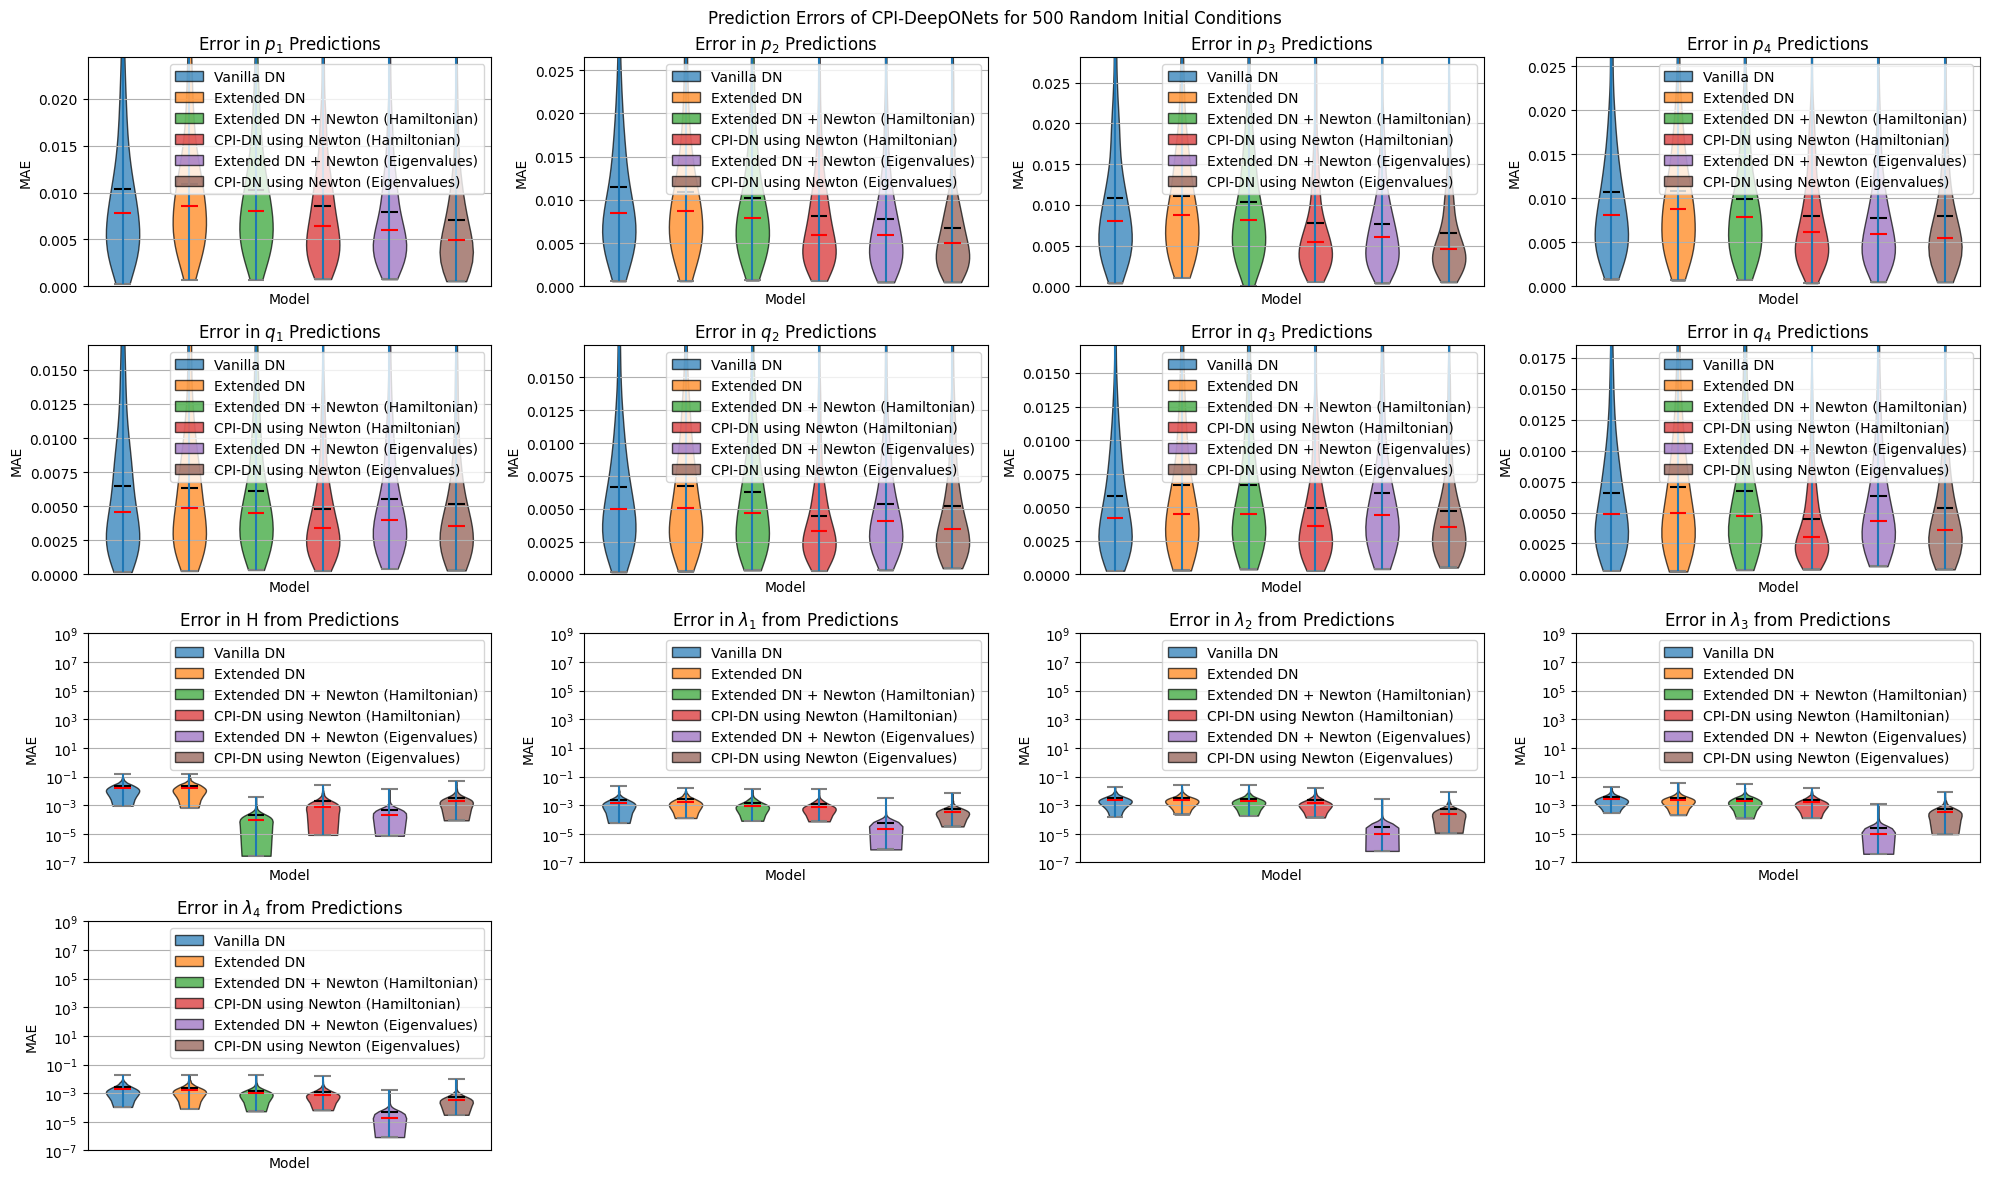

In [72]:
def run_test(num_vars, num_cons, num_models, num_exp, models_lst, params_lst, labels_lst, bfgs_lst, newton_H_lst, newton_eig_lst) :

    n = 500
    t = np.linspace(t0, tfinal, n)
    
    
    preds = np.zeros((num_exp, num_models, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    for i in range(num_exp) :

        print(i)

        p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p4_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q4_init = np.random.uniform(-1.0, 1.0, size=(1,))
        H_init = calc_H(p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init)
        evals_init = calc_evals_pq(p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init)
        e1_init, e2_init, e3_init, e4_init = evals_init[0], evals_init[1], evals_init[2], evals_init[3]
        
        
        data_model = np.column_stack([p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init])
        data_model = np.reshape(data_model, (-1,))
        data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
        
        H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        
        E_model = np.column_stack([e1_init, e2_init, e3_init, e4_init])
        E_model = np.reshape(E_model, (-1,))
        E_model = np.repeat(np.expand_dims(E_model, axis=0), n, axis=0)
        
        H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
                
        tHE_model = np.column_stack([t, H_model, E_model])
                
        data_rk = np.column_stack([p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = t
            
        sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], \
                                                                 sol_rk[:, 4], sol_rk[:, 5], sol_rk[:, 6], sol_rk[:, 7]
        H_rk = calc_H(p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk)

        evals_rk = jax.vmap(calc_evals_pq, (0), 0)(p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk)
        e1_rk, e2_rk, e3_rk, e4_rk = evals_rk[:, :1], evals_rk[:, 1:2], evals_rk[:, 2:3], evals_rk[:, 3:]
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]

            for k in range(num_vars - num_cons) :


                val = jax.vmap(model, [0, 0, None, None])(tHE_model, data_model, k, params)
                preds[i, j, k] = val

                
            preds[i, j, 8] = calc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3], \
                                    preds[i, j, 4], preds[i, j, 5], preds[i, j, 6], preds[i, j, 7])


            evals = jax.vmap(calc_evals_pq, (0), 0)(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3], \
                                                    preds[i, j, 4], preds[i, j, 5], preds[i, j, 6], preds[i, j, 7])

            preds[i, j, 9], preds[i, j, 10], preds[i, j, 11], preds[i, j, 12] = evals[:, 0], evals[:, 1], evals[:, 2], evals[:, 3]

            # if j in bfgs_lst :
                
            #     args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3]])
                
            #     H_arr = tH_model[:, 1:]
        
            #     xbfgs = find_min_bfgs(args_arr, H_arr)                

            #     for l in range(4) :

            #         preds[i, j, l] = xbfgs[:, l]

                
            #     preds[i, j, 4] = Hcalc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])  


            if j in newton_H_lst :
                
                args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3], \
                                            preds[i, j, 4], preds[i, j, 5], preds[i, j, 6], preds[i, j, 7]])
                
                H_arr = tHE_model[:, 1:2]
            
                xnewtonH = find_min_newton_H(args_arr, H_arr)                
            
                for l in range(num_vars - num_cons) :
            
                    preds[i, j, l] = xnewtonH[:, l]
            
                
                preds[i, j, 8] = calc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3], \
                                        preds[i, j, 4], preds[i, j, 5], preds[i, j, 6], preds[i, j, 7])

                evals = jax.vmap(calc_evals_pq, (0), 0)(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3], \
                                                        preds[i, j, 4], preds[i, j, 5], preds[i, j, 6], preds[i, j, 7])
                
                preds[i, j, 9], preds[i, j, 10], preds[i, j, 11], preds[i, j, 12] = evals[:, 0], evals[:, 1], evals[:, 2], evals[:, 3]
            
            
            if j in newton_eig_lst :
                
                args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3], \
                                           preds[i, j, 4], preds[i, j, 5], preds[i, j, 6], preds[i, j, 7]])
                
                E_arr = tHE_model[:, 2:]
            
                xnewtoneig = find_min_newton_eig(args_arr, E_arr)                
            
                for l in range(num_vars - num_cons) :
            
                    preds[i, j, l] = xnewtoneig[:, l]
            
                
                preds[i, j, 8] = calc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3], \
                                        preds[i, j, 4], preds[i, j, 5], preds[i, j, 6], preds[i, j, 7])

                evals = jax.vmap(calc_evals_pq, (0), 0)(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3], \
                                                        preds[i, j, 4], preds[i, j, 5], preds[i, j, 6], preds[i, j, 7])
                
                preds[i, j, 9], preds[i, j, 10], preds[i, j, 11], preds[i, j, 12] = evals[:, 0], evals[:, 1], evals[:, 2], evals[:, 3]
              

            for m in range(num_vars - num_cons) :

                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, m]))

            preds_error[i, j, 8] = np.mean(np.abs(H_rk - preds[i, j, 8]))
            preds_error[i, j, 9] = np.mean(np.abs(e1_rk - preds[i, j, 9]))
            preds_error[i, j, 10] = np.mean(np.abs(e2_rk - preds[i, j, 10]))
            preds_error[i, j, 11] = np.mean(np.abs(e3_rk - preds[i, j, 11]))
            preds_error[i, j, 12] = np.mean(np.abs(e4_rk - preds[i, j, 12]))
            
            


    x_labels = [r'$p_1$', r'$p_2$', r'$p_3$', r'$p_4$', r'$q_1$', r'$q_2$', r'$q_3$', r'$q_4$', \
                'H', r'$\lambda_1$', r'$\lambda_2$', r'$\lambda_3$', r'$\lambda_4$'] 
        
    # Set up the figure
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle('Prediction Errors of CPI-DeepONets for 500 Random Initial Conditions')
    
    # Define colors for each model (adjust color palette as needed)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']    # Example colors for each model
    
    for j in range(num_vars):
        plt.subplot(4, 4, j + 1)


        q1 = np.percentile(preds_error[:, 1, j], 25)
        q3 = np.percentile(preds_error[:, 1, j], 75)
        iqr = q3 - q1

        plt.ylim(0.0, q3 + 1.5 * iqr)
        
        # Prepare data for each model for the current variable (j)
        data = [preds_error[:, alpha, j] for alpha in range(num_models)]
        
        # Create the violin plot with custom colors
        vp = plt.violinplot(data, positions=range(num_models), showmeans=True, showmedians=True)
        
        # Customize the colors of the violins
        for i in range(num_models):
            vp['bodies'][i].set_facecolor(colors[i])  # Set face color for each model
            vp['bodies'][i].set_edgecolor('black')   # Set edge color for each model
            vp['bodies'][i].set_alpha(0.7)            # Set transparency
        
        # Customize mean and median lines
        vp['cmeans'].set_color('black')  # Mean line color
        vp['cmedians'].set_color('red')
        vp['cmins'].set_color('gray')
        vp['cmaxes'].set_color('gray')# Median line color
    
        # Add labels, title, and grid
        plt.ylabel("MAE")
        if j >= 8:
            plt.title("Error in " + x_labels[j] + " from Predictions")
        else:
            plt.title("Error in " + x_labels[j] + " Predictions")
        plt.grid(True, axis='y')
    
        # Add legend (outside the plot)
        plt.xticks([])  # Remove vertical axis ticks
        plt.xlabel("Model")  # Remove vertical axis label

        if j >= 8:
            plt.yscale('log')
            plt.ylim(10**(-7), 10**9)

    
        plt.legend(labels=labels_lst, loc='upper right')
    
    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()
    

    
    fig.savefig('Toda4_cpi_violinmae_5000+5000ep_500exps.png')
    return preds, preds_error, (p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk, H_rk)


preds, preds_error, (p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk, H_rk) = run_test(num_vars = 13, num_cons = 5, num_models = 6, num_exp = 500, \
         # models_lst = [var_model, var_model, ECvar_model],
         # params_lst = [params, params, ECparams],
         # labels_lst = ['Extended DN', 'Extended DN + Newton (Eigenvalues)', \
         #               'CPI-DN using Newton (Eigenvalues)'],                                                                                              
         models_lst = [Vvar_model, var_model, var_model, HCvar_model, var_model, ECvar_model], \
         params_lst = [Vparams, params, params, HCparams, params, ECparams], \
         labels_lst = ['Vanilla DN', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
                       'CPI-DN using Newton (Hamiltonian)', 'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Eigenvalues)'], \
         bfgs_lst = [], 
         newton_H_lst = [2],
         newton_eig_lst = [4])

In [ ]:
n = 500
t_tot = np.linspace(t0, tfinal, n)
model_no = -1
p1, p2, p3, q1, q2, q3, H = preds[model_no, 0, 0, :], preds[model_no, 0, 1, :], preds[model_no, 0, 2, :], \
                            preds[model_no, 0, 3, :], preds[model_no, 0, 4, :], preds[model_no, 0, 5, :], \
                            preds[model_no, 0, 6, :]

Hp1, Hp2, Hp3, Hq1, Hq2, Hq3, HH = preds[model_no, 1, 0, :], preds[model_no, 1, 1, :], preds[model_no, 1, 2, :], \
                                   preds[model_no, 1, 3, :], preds[model_no, 1, 4, :], preds[model_no, 1, 5, :], \
                                   preds[model_no, 1, 6, :]

Ep1, Ep2, Ep3, Eq1, Eq2, Eq3, EH = preds[model_no, 2, 0, :], preds[model_no, 2, 1, :], preds[model_no, 2, 2, :], \
                                   preds[model_no, 2, 3, :], preds[model_no, 2, 4, :], preds[model_no, 2, 5, :], \
                                   preds[model_no, 2, 6, :]


HCp1, HCp2, HCp3, HCq1, HCq2, HCq3, HCH = preds[model_no, 3, 0, :], preds[model_no, 3, 1, :], preds[model_no, 3, 2, :], \
                                          preds[model_no, 3, 3, :], preds[model_no, 3, 4, :], preds[model_no, 3, 5, :], \
                                          preds[model_no, 3, 6, :]


ECp1, ECp2, ECp3, ECq1, ECq2, ECq3, ECH = preds[model_no, 4, 0, :], preds[model_no, 4, 1, :], preds[model_no, 4, 2, :], \
                                          preds[model_no, 4, 3, :], preds[model_no, 4, 4, :], preds[model_no, 4, 5, :], \
                                          preds[model_no, 4, 6, :]



fig = plt.figure(figsize=(15, 10))
fig.suptitle("CPI-DeepONet Predictions for Random Initial Conditions")

plt.subplot(2, 3, 1)
plt.tight_layout()
plt.plot(t_tot, p1_rk)
plt.plot(t_tot, p1)
plt.plot(t_tot, Hp1)
plt.plot(t_tot, Ep1)
plt.plot(t_tot, HCp1)
plt.plot(t_tot, ECp1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_1$')
plt.title(r'$p_1$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])


plt.subplot(2, 3, 2)
plt.tight_layout()
plt.plot(t_tot, p2_rk)
plt.plot(t_tot, p2)
plt.plot(t_tot, Hp2)
plt.plot(t_tot, Ep2)
plt.plot(t_tot, HCp2)
plt.plot(t_tot, ECp2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_2$')
plt.title(r'$p_2$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 3)
plt.tight_layout()
plt.plot(t_tot, p3_rk)
plt.plot(t_tot, p3)
plt.plot(t_tot, Hp3)
plt.plot(t_tot, Ep3)
plt.plot(t_tot, HCp3)
plt.plot(t_tot, ECp3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_3$')
plt.title(r'$p_3$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 4)
plt.tight_layout()
plt.plot(t_tot, q1_rk)
plt.plot(t_tot, q1)
plt.plot(t_tot, Hq1)
plt.plot(t_tot, Eq1)
plt.plot(t_tot, HCq1)
plt.plot(t_tot, ECq1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_1$')
plt.title(r'$q_1$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 5)
plt.tight_layout()
plt.plot(t_tot, q2_rk)
plt.plot(t_tot, q2)
plt.plot(t_tot, Hq2)
plt.plot(t_tot, Eq2)
plt.plot(t_tot, HCq2)
plt.plot(t_tot, ECq2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_2$')
plt.title(r'$q_2$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 6)
plt.tight_layout()
plt.plot(t_tot, q3_rk)
plt.plot(t_tot, q3)
plt.plot(t_tot, Hq3)
plt.plot(t_tot, Eq3)
plt.plot(t_tot, HCq3)
plt.plot(t_tot, ECq3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_3$')
plt.title(r'$q_3$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

#fig.savefig('Toda3_cpi_preds_2500+2500ep.png')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


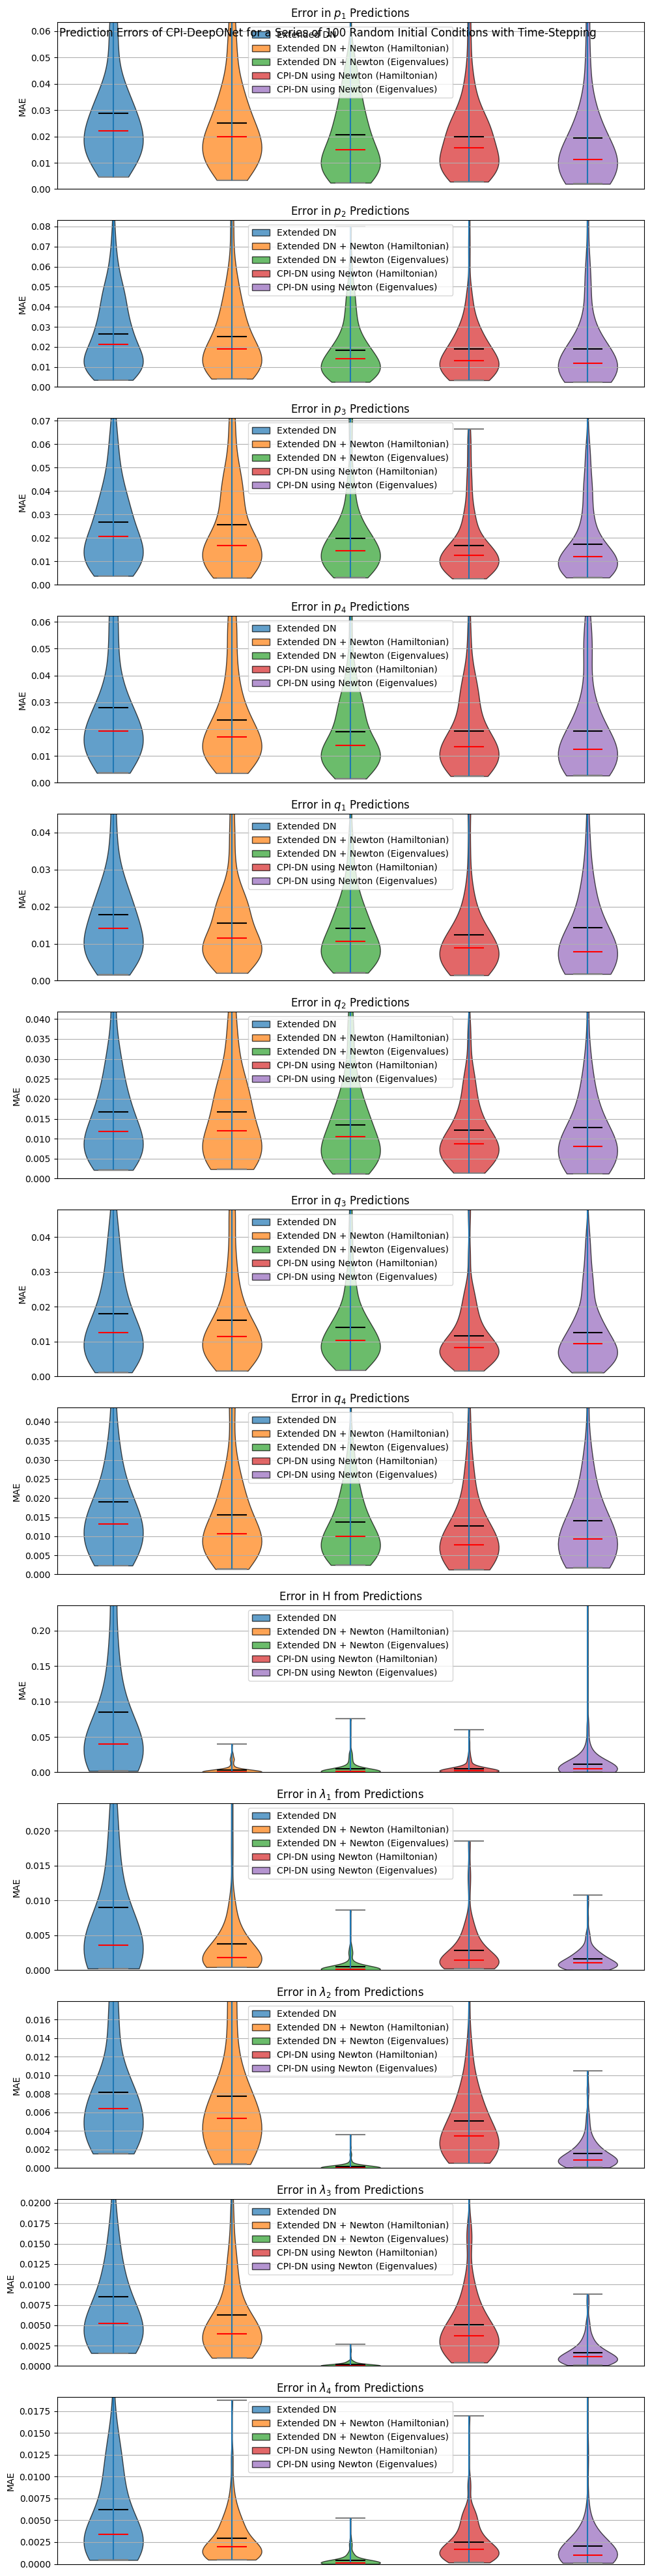

In [137]:
def tt_run_test(num_vars, num_cons, num_models, num_exp, models_lst, params_lst, labels_lst, newton_H_lst, newton_eig_lst, bfgs_lst, t_end) :

    n = 500

    num_cycles = int(t_end/tfinal)
    n_ts = n*num_cycles
    t_step = tfinal/n

    
    preds = np.zeros((num_exp, num_models, num_cycles, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    for i in range(num_exp) :

        print(i)

        p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p4_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q4_init = np.random.uniform(-1.0, 1.0, size=(1,))
        H_init = calc_H(p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init)
        evals_init = calc_evals_pq(p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init)
        e1_init, e2_init, e3_init, e4_init = evals_init[0], evals_init[1], evals_init[2], evals_init[3]
        
        data_model = np.column_stack([p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init])
        data_model = np.reshape(data_model, (-1,))
        data_model_0 = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)

        H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        
        E_model = np.column_stack([e1_init, e2_init, e3_init, e4_init])
        E_model = np.reshape(E_model, (-1,))
        E_model = np.repeat(np.expand_dims(E_model, axis=0), n, axis=0)

        t = np.linspace(t0, tfinal, n)
                
        tHE_model_0 = np.column_stack([t, H_model, E_model])
                        
        data_rk = np.column_stack([p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = np.linspace(t0, t_end, n_ts)
        
        sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], \
                                                                 sol_rk[:, 4], sol_rk[:, 5], sol_rk[:, 6], sol_rk[:, 7]
        H_rk = calc_H(p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk)
        
        evals_rk = jax.vmap(calc_evals_pq, (0), 0)(p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk)
        e1_rk, e2_rk, e3_rk, e4_rk = evals_rk[:, :1], evals_rk[:, 1:2], evals_rk[:, 2:3], evals_rk[:, 3:]

        
        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]


            for c in range(num_cycles) :

                if c != 0 :

                    p1_init = preds[i, j, c - 1, 0, -1]
                    p2_init = preds[i, j, c - 1, 1, -1]
                    p3_init = preds[i, j, c - 1, 2, -1]
                    p4_init = preds[i, j, c - 1, 3, -1]
                    q1_init = preds[i, j, c - 1, 4, -1]
                    q2_init = preds[i, j, c - 1, 5, -1]
                    q3_init = preds[i, j, c - 1, 6, -1]
                    q4_init = preds[i, j, c - 1, 7, -1]
                    H_init = calc_H(p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init)
                    evals_init = calc_evals_pq(p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init)
                    e1_init, e2_init, e3_init, e4_init = evals_init[0], evals_init[1], evals_init[2], evals_init[3]
                    
                    data_model = np.column_stack([p1_init, p2_init, p3_init, p4_init, q1_init, q2_init, q3_init, q4_init])
                    data_model = np.reshape(data_model, (-1,))
                    data_model = np.repeat(np.expand_dims(data_model, axis=0), n + 1, axis=0)
            
                    H_model = np.repeat(np.expand_dims(H_init, axis=0), n + 1, axis=0)
                    
                    E_model = np.column_stack([e1_init, e2_init, e3_init, e4_init])
                    E_model = np.reshape(E_model, (-1,))
                    E_model = np.repeat(np.expand_dims(E_model, axis=0), n + 1, axis=0)

                    t = np.linspace(t0, tfinal + t_step, n + 1)
                            
                    tHE_model = np.column_stack([t, H_model, E_model])  

                else:

                    data_model = data_model_0
                    tHE_model = tHE_model_0

                
                for k in range(num_vars - num_cons) :
    
                    val = jax.vmap(model, [0, 0, None, None])(tHE_model, data_model, k, params)

                    if c != 0 :
                        preds[i, j, c, k] = val[1:]

                    else:
                        preds[i, j, c, k] = val                        
    
                preds[i, j, c, 8] = calc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3], \
                                           preds[i, j, c, 4], preds[i, j, c, 5], preds[i, j, c, 6], preds[i, j, c, 7])

                evals = jax.vmap(calc_evals_pq, (0), 0)(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3], \
                                                        preds[i, j, c, 4], preds[i, j, c, 5], preds[i, j, c, 6], preds[i, j, c, 7])
                
                preds[i, j, c, 9], preds[i, j, c, 10], preds[i, j, c, 11], preds[i, j, c, 12] = evals[:, 0], evals[:, 1], evals[:, 2], evals[:, 3]



                if j in newton_H_lst :
                    
                    args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3], \
                                                preds[i, j, c, 4], preds[i, j, c, 5], preds[i, j, c, 6], preds[i, j, c, 7]])
                    
                    H_arr = tHE_model[:, 1:2] if c == 0 else tHE_model[1:, 1:2]
            
                    xnewtonH = find_min_newton_H(args_arr, H_arr)                
    
                    for l in range(num_vars - num_cons) :
    
                        preds[i, j, c, l] = xnewtonH[:, l]
    
                    
                    preds[i, j, c, 8] = calc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3], \
                                               preds[i, j, c, 4], preds[i, j, c, 5], preds[i, j, c, 6], preds[i, j, c, 7])
    
                    evals = jax.vmap(calc_evals_pq, (0), 0)(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3], \
                                                            preds[i, j, c, 4], preds[i, j, c, 5], preds[i, j, c, 6], preds[i, j, c, 7])
                    
                    preds[i, j, c, 9], preds[i, j, c, 10], preds[i, j, c, 11], preds[i, j, c, 12] = evals[:, 0], evals[:, 1], evals[:, 2], evals[:, 3]


                if j in newton_eig_lst :
                    
                    args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3], \
                                                preds[i, j, c, 4], preds[i, j, c, 5], preds[i, j, c, 6], preds[i, j, c, 7]])
                                        
                    E_arr = tHE_model[:, 2:] if c == 0 else tHE_model[1:, 2:]
            
                    xnewtoneig = find_min_newton_eig(args_arr, E_arr)                
    
                    for l in range(num_vars - num_cons) :
    
                        preds[i, j, c, l] = xnewtoneig[:, l]
    
                    
                    preds[i, j, c, 8] = calc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3], \
                                               preds[i, j, c, 4], preds[i, j, c, 5], preds[i, j, c, 6], preds[i, j, c, 7])
    
                    evals = jax.vmap(calc_evals_pq, (0), 0)(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3], \
                                                            preds[i, j, c, 4], preds[i, j, c, 5], preds[i, j, c, 6], preds[i, j, c, 7])
                    
                    preds[i, j, c, 9], preds[i, j, c, 10], preds[i, j, c, 11], preds[i, j, c, 12] = evals[:, 0], evals[:, 1], evals[:, 2], evals[:, 3]

                   
                # if j in bfgs_lst :
                    
                #     args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3]])
                    
                #     E_arr = tE_model[:, 1:] if c == 0 else tE_model[1:, 1:]
            
                #     xbfgs = find_min_bfgs(args_arr, E_arr)                
    
                #     for l in range(num_vars - 1) :
    
                #         preds[i, j, c, l] = xbfgs[:, l]
    
                    
                #     preds[i, j, c, 4] = calc_E(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3])  
                  
    
            for m in range(num_vars - num_cons) :
    
                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, :, m].flatten()))
    
            preds_error[i, j, 8] = np.mean(np.abs(H_rk - preds[i, j, :, 8].flatten()))
            preds_error[i, j, 9] = np.mean(np.abs(e1_rk - preds[i, j, :, 9].flatten()))
            preds_error[i, j, 10] = np.mean(np.abs(e2_rk - preds[i, j, :, 10].flatten()))
            preds_error[i, j, 11] = np.mean(np.abs(e3_rk - preds[i, j, :, 11].flatten()))
            preds_error[i, j, 12] = np.mean(np.abs(e4_rk - preds[i, j, :, 12].flatten()))
            


    x_labels = [r'$p_1$', r'$p_2$', r'$p_3$', r'$p_4$', r'$q_1$', r'$q_2$', r'$q_3$', r'$q_4$', \
                'H', r'$\lambda_1$', r'$\lambda_2$', r'$\lambda_3$', r'$\lambda_4$'] 
        
    fig = plt.figure(figsize=(10, 40))
    fig.suptitle('Prediction Errors of CPI-DeepONet for a Series of 100 Random Initial Conditions with Time-Stepping')
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for j in range(num_vars):
        
        plt.subplot(13, 1, j + 1)

        q1 = np.percentile(preds_error[:, 0, j], 25)
        q3 = np.percentile(preds_error[:, 0, j], 75)
        iqr = q3 - q1

        plt.ylim(0.0, q3 + 1.5 * iqr) 
        
        data = [preds_error[:, alpha, j] for alpha in range(num_models)]
        
        vp = plt.violinplot(data, positions=range(num_models), showmeans=True, showmedians=True)
        
        for i in range(num_models):
            vp['bodies'][i].set_facecolor(colors[i])  # Set face color for each model
            vp['bodies'][i].set_edgecolor('black')   # Set edge color for each model
            vp['bodies'][i].set_alpha(0.7)            # Set transparency
        
        vp['cmeans'].set_color('black')
        vp['cmedians'].set_color('red')
        vp['cmins'].set_color('gray')
        vp['cmaxes'].set_color('gray')
    
        plt.ylabel("MAE")
        if j >= 8:
            plt.title("Error in " + x_labels[j] + " from Predictions")
        else:
            plt.title("Error in " + x_labels[j] + " Predictions")
        plt.grid(True, axis='y')
    
        plt.xticks([])  
        plt.xlabel("")  
        plt.legend(labels=labels_lst)
        
    plt.tight_layout()
    plt.show()
    

    #fig.savefig('Toda4_tt5.0_violinmae_2500+2500ep_100exps.png')
    return preds, preds_error, (p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk, H_rk, e1_rk, e2_rk, e3_rk, e4_rk)


t_end_val = 3.0

preds, preds_error, (p1_rk, p2_rk, p3_rk, p4_rk, q1_rk, q2_rk, q3_rk, q4_rk, H_rk, e1_rk, e2_rk, e3_rk, e4_rk) = tt_run_test(num_vars = 13, num_cons = 5, num_models = 5, \
                                                                                                                             num_exp = 100, \
                                       models_lst = [var_model, var_model, var_model, HCvar_model, ECvar_model], \
                                       params_lst = [params, params, params, HCparams, ECparams], \
                                       labels_lst = ['Extended DN', 'Extended DN + Newton (Hamiltonian)', 'Extended DN + Newton (Eigenvalues)', \
                                                     'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'], \
                                       bfgs_lst = [], \
                                       newton_H_lst = [1], \
                                       newton_eig_lst = [2], \
                                       t_end = t_end_val)

In [ ]:
n = 500
t_end = t_end_val

num_cycles = int(t_end/tfinal)
n_tot = n*num_cycles
t_tot = np.linspace(t0, t_end, n_tot)

model_no = -1

p1, p2, p3, p4, q1, q2, q3, q4, H = preds[model_no, 0, :, 0, :].flatten(), preds[model_no, 0, :, 1, :].flatten(), preds[model_no, 0, :, 2, :].flatten(), \
                                    preds[model_no, 0, :, 3, :].flatten(), preds[model_no, 0, :, 4, :].flatten(), preds[model_no, 0, :, 5, :].flatten(), \
                                    preds[model_no, 0, :, 6, :].flatten(), preds[model_no, 0, :, 7, :].flatten(), preds[model_no, 0, :, 8, :].flatten()

Hp1, Hp2, Hp3, Hp4, Hq1, Hq2, Hq3, Hq4, HH = preds[model_no, 1, :, 0, :].flatten(), preds[model_no, 1, :, 1, :].flatten(), preds[model_no, 1, :, 2, :].flatten(), \
                                   preds[model_no, 1, :, 3, :].flatten(), preds[model_no, 1, :, 4, :].flatten(), preds[model_no, 1, :, 5, :].flatten(), \
                                   preds[model_no, 1, :, 6, :].flatten(), preds[model_no, 1, :, 7, :].flatten(), preds[model_no, 1, :, 8, :].flatten()

Ep1, Ep2, Ep3, Ep4, Eq1, Eq2, Eq3, Eq4, EH = preds[model_no, 2, :, 0, :].flatten(), preds[model_no, 2, :, 1, :].flatten(), preds[model_no, 2, :, 2, :].flatten(), \
                                   preds[model_no, 2, :, 3, :].flatten(), preds[model_no, 2, :, 4, :].flatten(), preds[model_no, 2, :, 5, :].flatten(), \
                                   preds[model_no, 2, :, 6, :].flatten(), preds[model_no, 2, :, 7, :].flatten(), preds[model_no, 2, :, 8, :].flatten()


HCp1, HCp2, HCp3, HCp4, HCq1, HCq2, HCq3, HCq4, HCH = preds[model_no, 3, :, 0, :].flatten(), preds[model_no, 3, :, 1, :].flatten(), preds[model_no, 3, :, 2, :].flatten(), \
                                          preds[model_no, 3, :, 3, :].flatten(), preds[model_no, 3, :, 4, :].flatten(), preds[model_no, 3, :, 5, :].flatten(), \
                                          preds[model_no, 3, :, 6, :].flatten(), preds[model_no, 3, :, 7, :].flatten(), preds[model_no, 3, :, 8, :].flatten()


ECp1, ECp2, ECp3, ECp4, ECq1, ECq2, ECq3, ECq4, ECH = preds[model_no, 4, :, 0, :].flatten(), preds[model_no, 4, :, 1, :].flatten(), preds[model_no, 4, :, 2, :].flatten(), \
                                          preds[model_no, 4, :, 3, :].flatten(), preds[model_no, 4, :, 4, :].flatten(), preds[model_no, 4, :, 5, :].flatten(), \
                                          preds[model_no, 4, :, 6, :].flatten(), preds[model_no, 4, :, 7, :].flatten(), preds[model_no, 4, :, 8, :].flatten()





fig = plt.figure(figsize=(15, 10))
fig.suptitle("CPI-DeepONet Predictions for Random Initial Conditions with Time-Stepping")

plt.subplot(4, 2, 1)
plt.tight_layout()
plt.plot(t_tot, p1_rk)
plt.plot(t_tot, p1)
plt.plot(t_tot, Hp1)
plt.plot(t_tot, Ep1)
plt.plot(t_tot, HCp1)
plt.plot(t_tot, ECp1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_1$')
plt.title(r'$p_1$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])


plt.subplot(4, 2, 2)
plt.tight_layout()
plt.plot(t_tot, p2_rk)
plt.plot(t_tot, p2)
plt.plot(t_tot, Hp2)
plt.plot(t_tot, Ep2)
plt.plot(t_tot, HCp2)
plt.plot(t_tot, ECp2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_2$')
plt.title(r'$p_2$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(4, 2, 3)
plt.tight_layout()
plt.plot(t_tot, p3_rk)
plt.plot(t_tot, p3)
plt.plot(t_tot, Hp3)
plt.plot(t_tot, Ep3)
plt.plot(t_tot, HCp3)
plt.plot(t_tot, ECp3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_3$')
plt.title(r'$p_3$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(4, 2, 4)
plt.tight_layout()
plt.plot(t_tot, p4_rk)
plt.plot(t_tot, p4)
plt.plot(t_tot, Hp4)
plt.plot(t_tot, Ep4)
plt.plot(t_tot, HCp4)
plt.plot(t_tot, ECp4)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_4$')
plt.title(r'$p_4$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])


plt.subplot(4, 2, 5)
plt.tight_layout()
plt.plot(t_tot, q1_rk)
plt.plot(t_tot, q1)
plt.plot(t_tot, Hq1)
plt.plot(t_tot, Eq1)
plt.plot(t_tot, HCq1)
plt.plot(t_tot, ECq1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_1$')
plt.title(r'$q_1$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(4, 2, 6)
plt.tight_layout()
plt.plot(t_tot, q2_rk)
plt.plot(t_tot, q2)
plt.plot(t_tot, Hq2)
plt.plot(t_tot, Eq2)
plt.plot(t_tot, HCq2)
plt.plot(t_tot, ECq2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_2$')
plt.title(r'$q_2$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(4, 2, 7)
plt.tight_layout()
plt.plot(t_tot, q3_rk)
plt.plot(t_tot, q3)
plt.plot(t_tot, Hq3)
plt.plot(t_tot, Eq3)
plt.plot(t_tot, HCq3)
plt.plot(t_tot, ECq3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_3$')
plt.title(r'$q_3$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(4, 2, 8)
plt.tight_layout()
plt.plot(t_tot, q4_rk)
plt.plot(t_tot, q4)
plt.plot(t_tot, Hq4)
plt.plot(t_tot, Eq4)
plt.plot(t_tot, HCq4)
plt.plot(t_tot, ECq4)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_4$')
plt.title(r'$q_4$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

#fig.savefig("Toda3_cpi_preds_2500+2500ep.png")